In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

import scanpy as sc
import scvi



plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [2]:
scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))


colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, colors_list))

# The standard "Scanpy / Vega / Tableau 20" list
scanpy_20 = [
    '#1f77b4', '#aec7e8', # Blue pair
    '#ff7f0e', '#ffbb78', # Orange pair
    '#2ca02c', '#98df8a', # Green pair
    '#d62728', '#ff9896', # Red pair
    '#9467bd', '#c5b0d5', # Purple pair
    '#8c564b', '#c49c94', # Brown pair
    '#e377c2', '#f7b6d2', # Pink pair
    '#7f7f7f', '#c7c7c7', # Grey pair
    '#bcbd22', '#dbdb8d', # Olive pair
    '#17becf', '#9edae5'  # Cyan pair
]

In [3]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 2 + [jitter_width] * 2  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))

In [4]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size


# RNA clustering

In [5]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')

union_bc_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_bc_df = pd.read_csv(union_bc_file,  sep='\t', index_col=0)
union_bc_df.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


In [6]:
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')
h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [8]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
SCVI_LATENT_KEY = "RNA_scVI"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI"


print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()


# clustering using scVI latent representation via Leiden
rna_resolution = 0.6
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=rna_resolution)

Save integrated samples into .h5ad file and trained SCVI model into subfolder

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:905: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (S

In [10]:
h5_rna_union.layers['log1p_counts'] = np.log1p(h5_rna_union.X)
h5_rna_union.layers['cpm'] = sc.pp.normalize_total(h5_rna_union, target_sum=1e4, inplace=False)['X']
h5_rna_union.layers['log1p_cpm'] = np.log1p(h5_rna_union.layers['cpm'])

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


### Vis on RNA spcae

In [11]:
print('Total number of barcodes that pass at least one of the three ATAC-based filtering methods: ', union_bc_df.shape[0])
print('Among those barcodes, number of barcodes that has RNA information: ', h5_rna_union.shape[0])

Total number of barcodes that pass at least one of the three ATAC-based filtering methods:  2384
Among those barcodes, number of barcodes that has RNA information:  2381


In [12]:
# 3 cells do not have RNA info at all 
bc_wo_RNAinfo_list = union_bc_df.index[~union_bc_df.index.isin(h5_rna_union.obs['atac_barcodes'])]
union_bc_df.loc[bc_wo_RNAinfo_list]

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
CGAATAATCTCACTTC,1377,False,True,False,entropy_only,entropy_only,ACACTTAAGTGATTCA,False,0.169662,no_rna_info,NO,SADE unique
CGGTTTATCCTAAATC,1236,False,True,False,entropy_only,entropy_only,ATGGCTTAGGAGCAAC,False,0.242614,no_rna_info,NO,SADE unique
GTTAGGAGTGCTCATG,352,False,True,False,entropy_only,entropy_only,CCTGTAACAACTGGGA,False,0.087141,no_rna_info,NO,SADE unique


In [13]:
col_list = ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'Entropy', '_3set_identified_by_atac', 'DNA_debris']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_bc_df[col])

In [14]:
h5_rna_union

AnnData object with n_obs × n_vars = 2381 × 21805
    obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%', '_scvi_batch', '_scvi_labels', 'leiden_RNA_scVI', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'Entropy', '_3set_identified_by_atac', 'DNA_debris'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden_RNA_scVI'
    obsm: 'RNA_scVI', 'X_umap'
    layers: 'counts', 'log1p_counts', 'cpm', 'log1p_cpm'
    obsp: 'distances', 'connectivities'

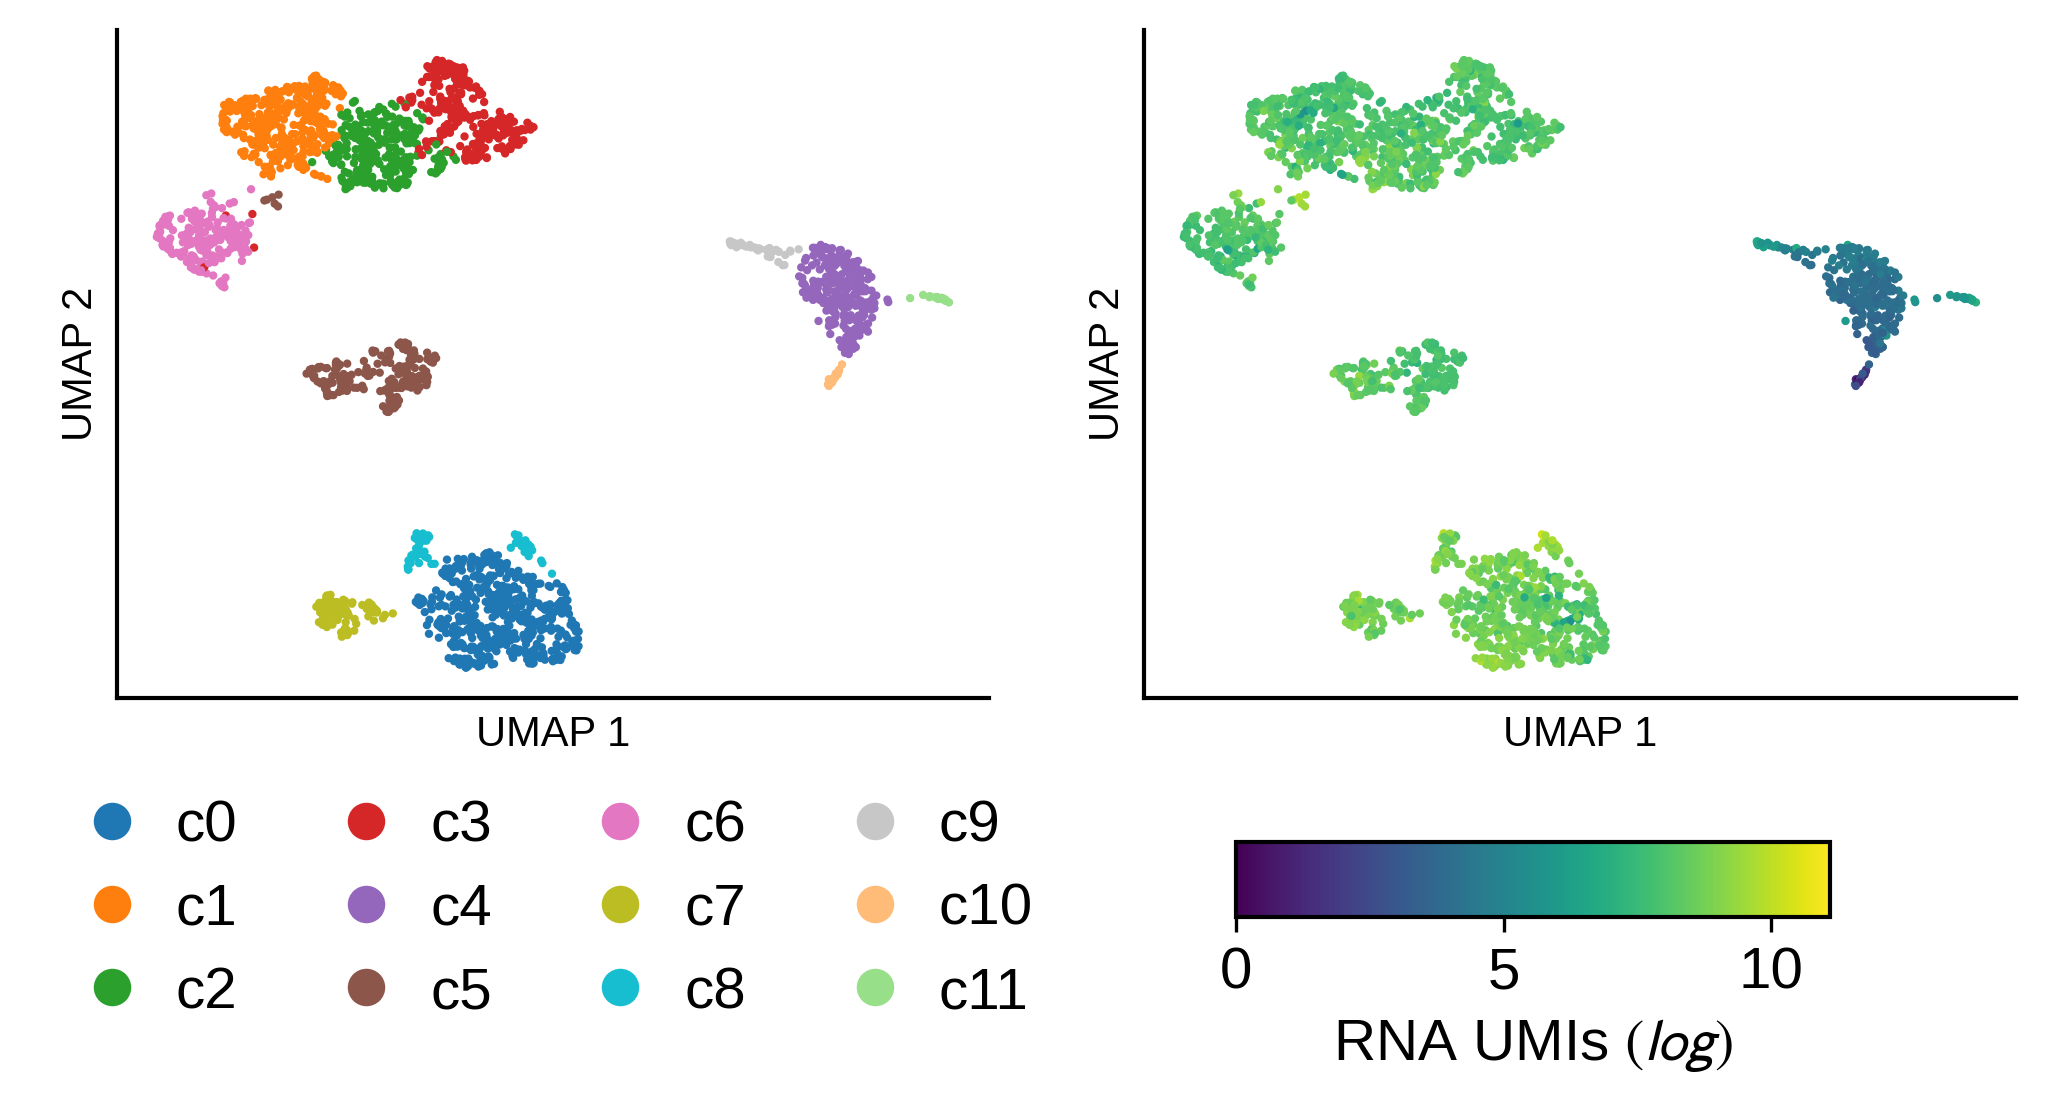

In [43]:
fig = plt.figure(layout="constrained", figsize=(6.6, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[1,1])

row1 = gs[0].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.1)
# blank = gs[1].subgridspec(1, 1)
# blank_ax = fig.add_subplot(blank[0, 0])
# blank_ax.axis('off')
ax = fig.add_subplot(row1[0, 0])
ax1 = fig.add_subplot(row1[0, 1])

_ = ax.scatter(h5_rna_union.obsm['X_umap'][:, 0], h5_rna_union.obsm['X_umap'][:, 1], 
               s=1, color=h5_rna_union.obs['leiden_RNA_scVI'].map(scanpy_color_map), alpha=1)
handles = [Line2D([0], [0], marker='o', color='w', label=f'c{c}', markerfacecolor=scanpy_color_map[c], markersize=10) for c in h5_rna_union.obs['leiden_RNA_scVI'].cat.categories]
legend_cbar_ax = fig.add_axes([0.25, 0.37, 0.3, 0.05])
legend_cbar_ax.axis('off')
legend_cbar_ax.legend(handles=handles, title="", loc='center', bbox_to_anchor=(0.0, 0.7),  frameon=False, ncol=4, handletextpad=0.1, columnspacing=1.2, labelspacing=0.5)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

v1 = ax1.scatter(h5_rna_union.obsm['X_umap'][:, 0], h5_rna_union.obsm['X_umap'][:, 1], 
               s=1, c=h5_rna_union.obs['total_RNA_UMI_log'], cmap='viridis')
cbar_ax = fig.add_axes([0.6, 0.4, 0.3, 0.05])

cbar = fig.colorbar(v1, cax=cbar_ax, orientation='horizontal', shrink=0.6, label='RNA UMIs $(log)$')

for a in [ax, ax1]:
    a.set_xticks([]); a.set_yticks([]) # Standard for UMAPs
    a.set_xlabel("UMAP 1", fontsize=10)
    a.set_ylabel("UMAP 2", fontsize=10)
    a.spines[['top', 'right']].set_visible(False)

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p1.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p1.pdf'), bbox_inches='tight')

Text(0, 0.5, 'UMAP 2')

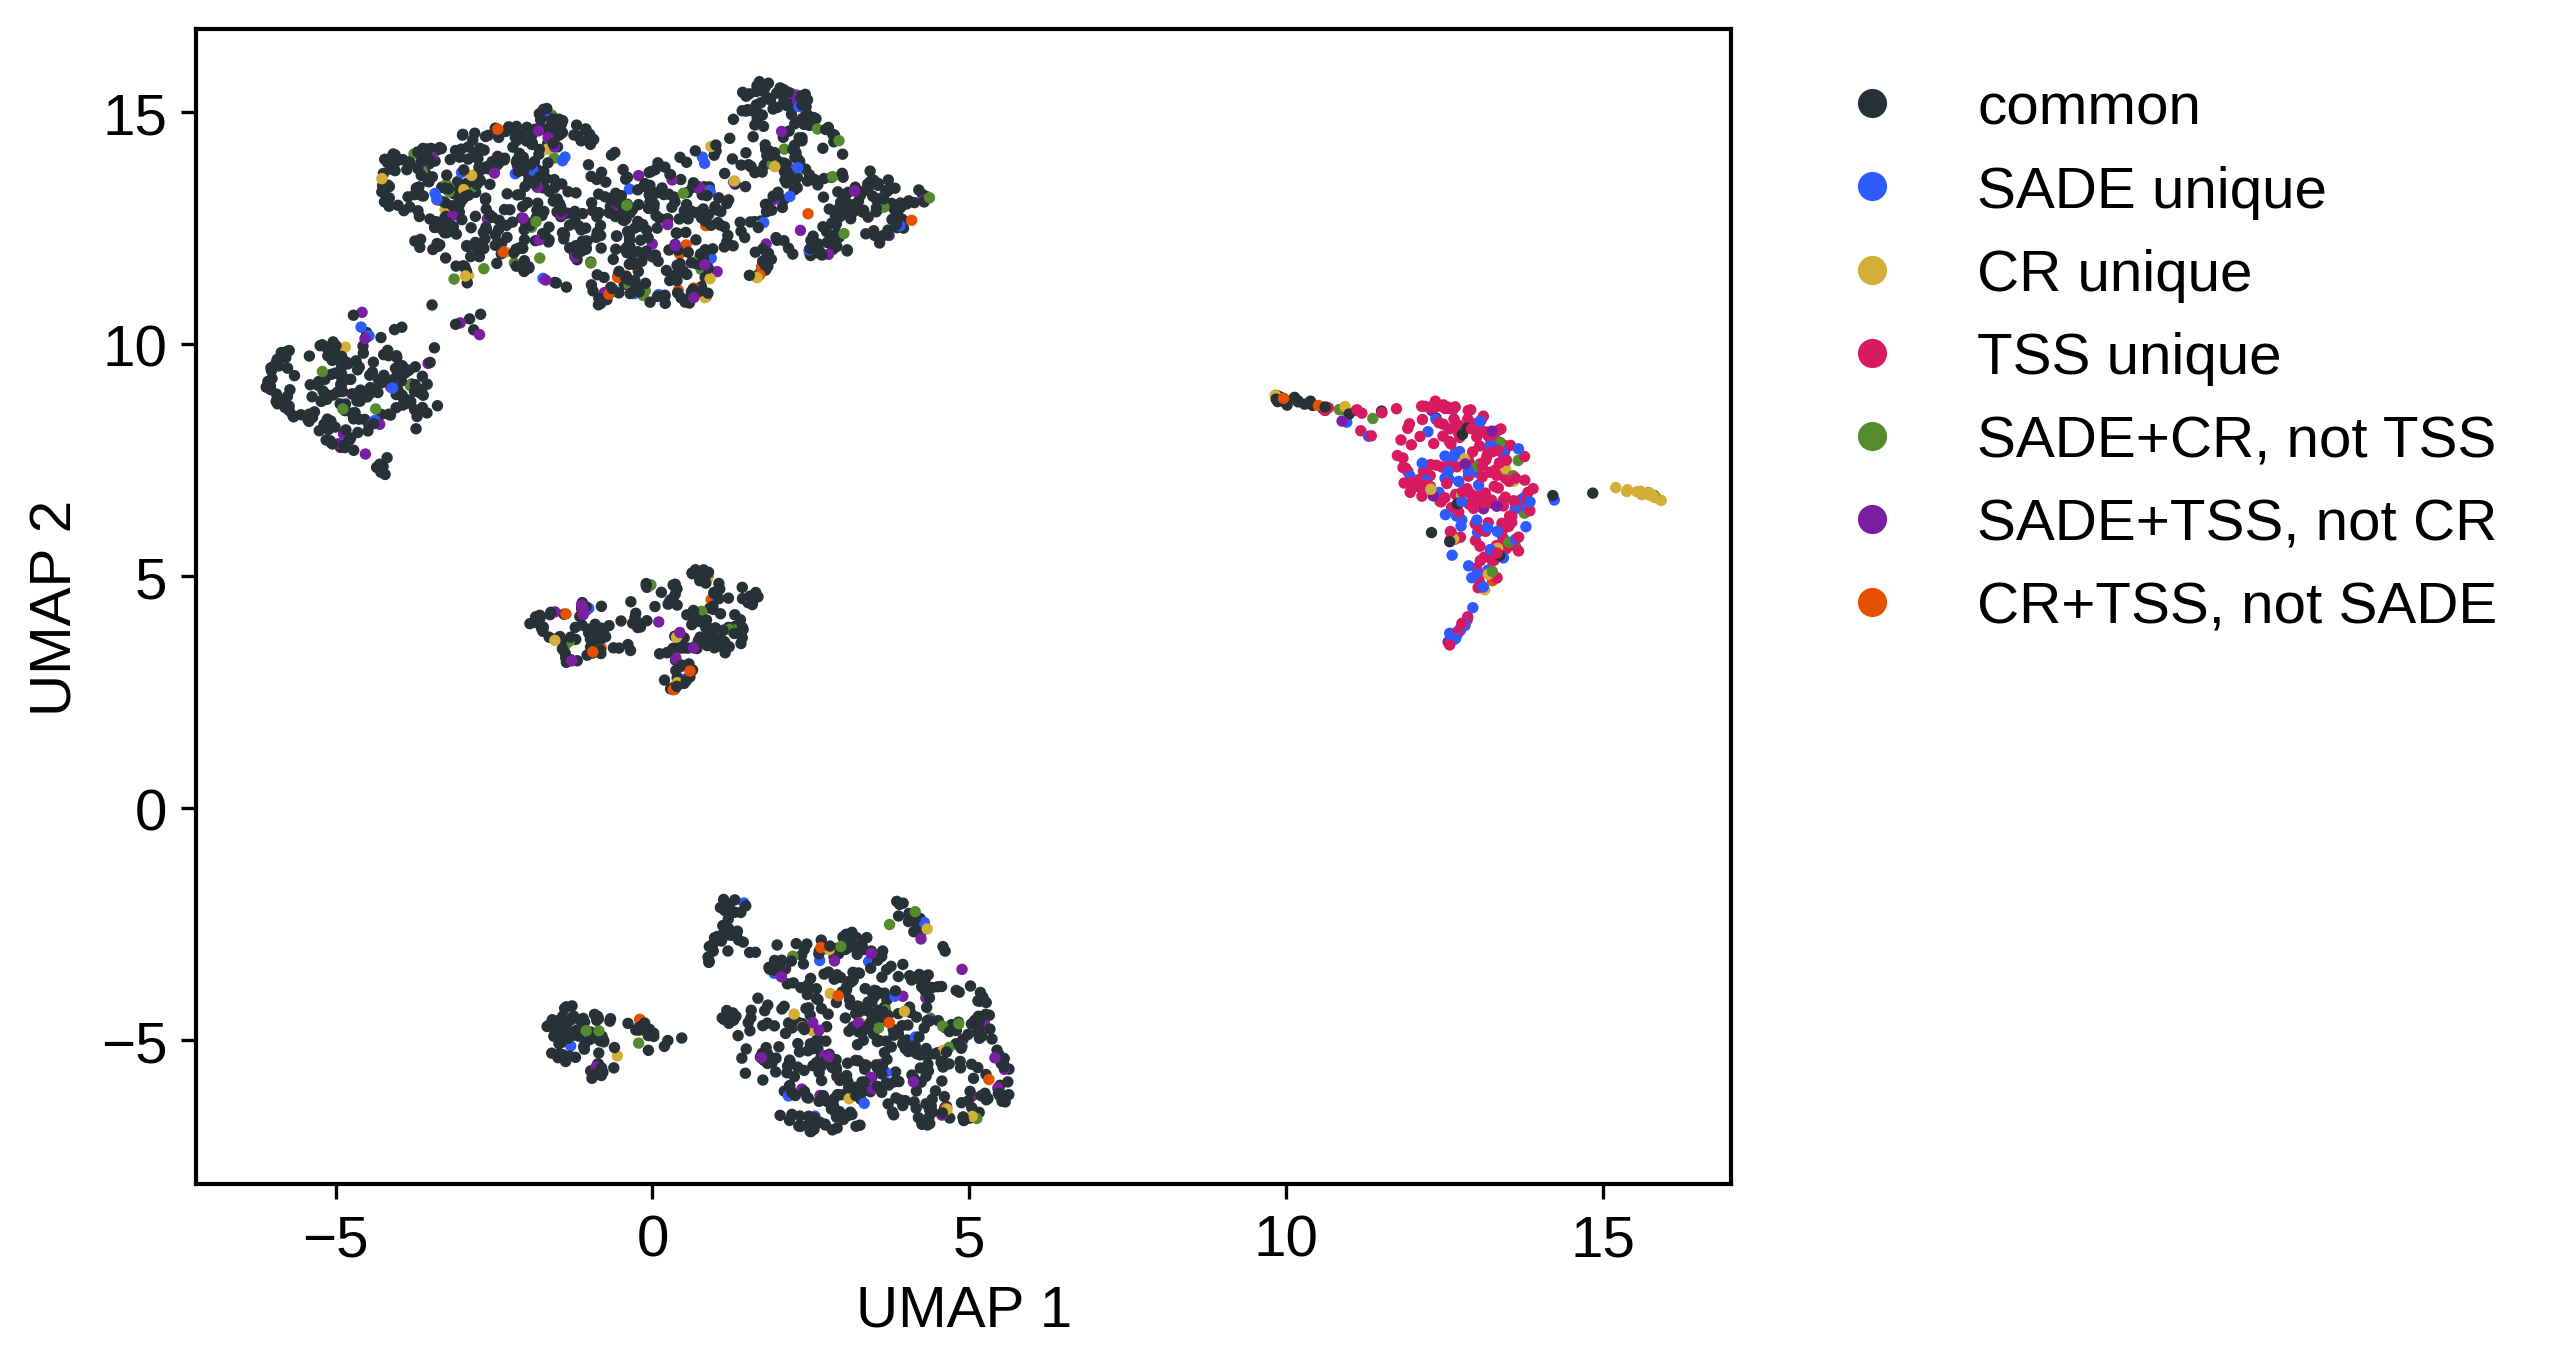

In [16]:
fig, ax = plt.subplots(figsize=(6.6, 5))

_ = ax.scatter(h5_rna_union.obsm['X_umap'][:, 0], h5_rna_union.obsm['X_umap'][:, 1], 
               s=3, color=h5_rna_union.obs['_3set_identified_by_atac'].map(cat_colors_map), alpha=1)
handles = [Line2D([0], [0], marker='o', color='w', label=cat, markerfacecolor=color, markersize=8) for cat, color in cat_colors_map.items()]
ax.legend(handles=handles, title="", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
# ax.set_title("RNA space umap")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

In [17]:
h5_rna_union.obs['ATAC_read_depth'] = h5_rna_union.obs['atac_barcodes'].map(union_bc_df['total_fragments'])
h5_rna_union.obs['log_ATAC_read_depth'] = np.log1p(h5_rna_union.obs['ATAC_read_depth'])

Text(0, 0.5, 'UMAP 2')

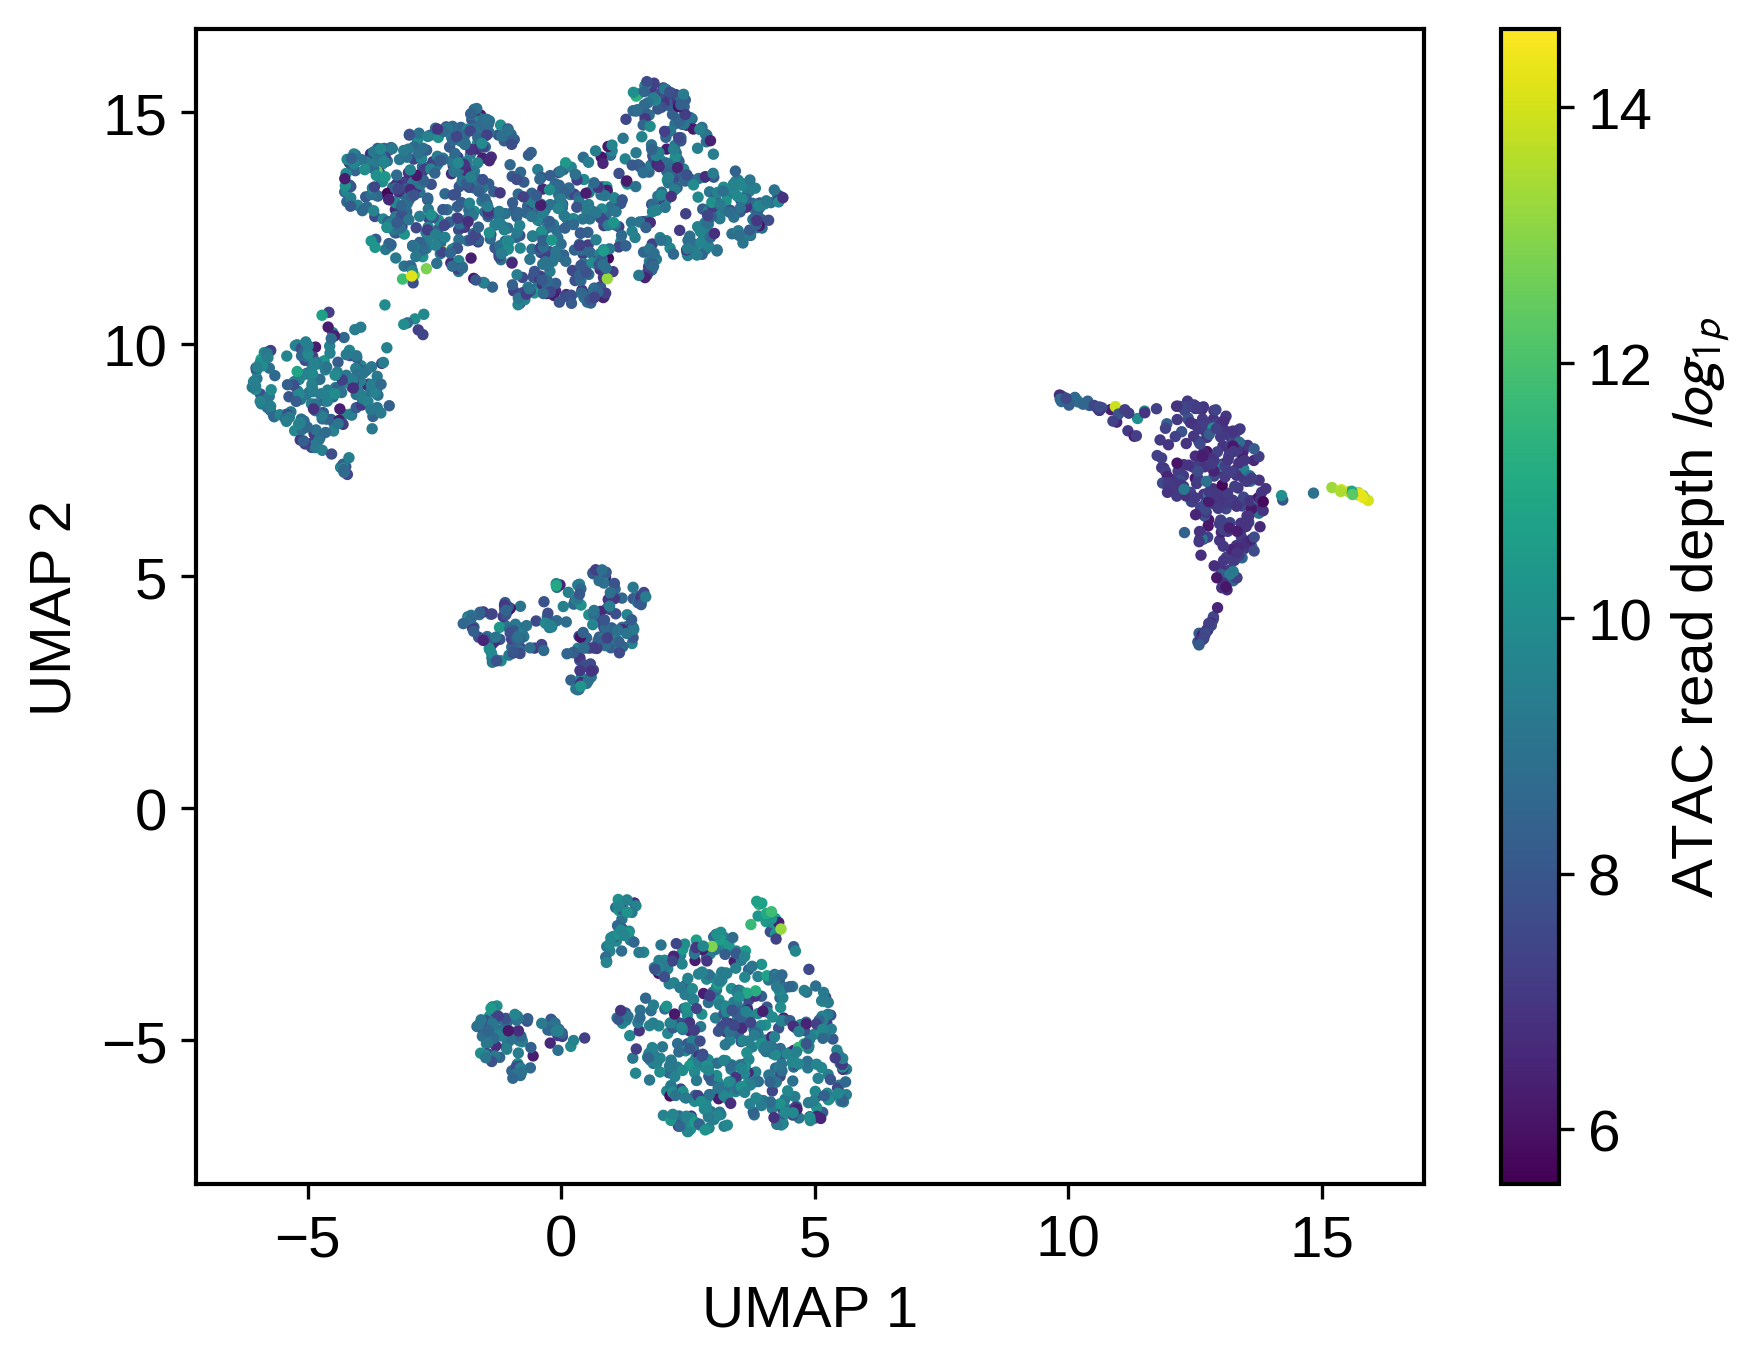

In [18]:
fig, ax = plt.subplots(figsize=(6.6, 5))

_ = ax.scatter(h5_rna_union.obsm['X_umap'][:, 0], h5_rna_union.obsm['X_umap'][:, 1], 
               s=3, c=h5_rna_union.obs['log_ATAC_read_depth'])
fig.colorbar(ax.collections[0], ax=ax, orientation='vertical', label='ATAC read depth $log_{1p}$')
# ax.set_title("RNA space umap")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

Text(0, 0.5, 'UMAP 2')

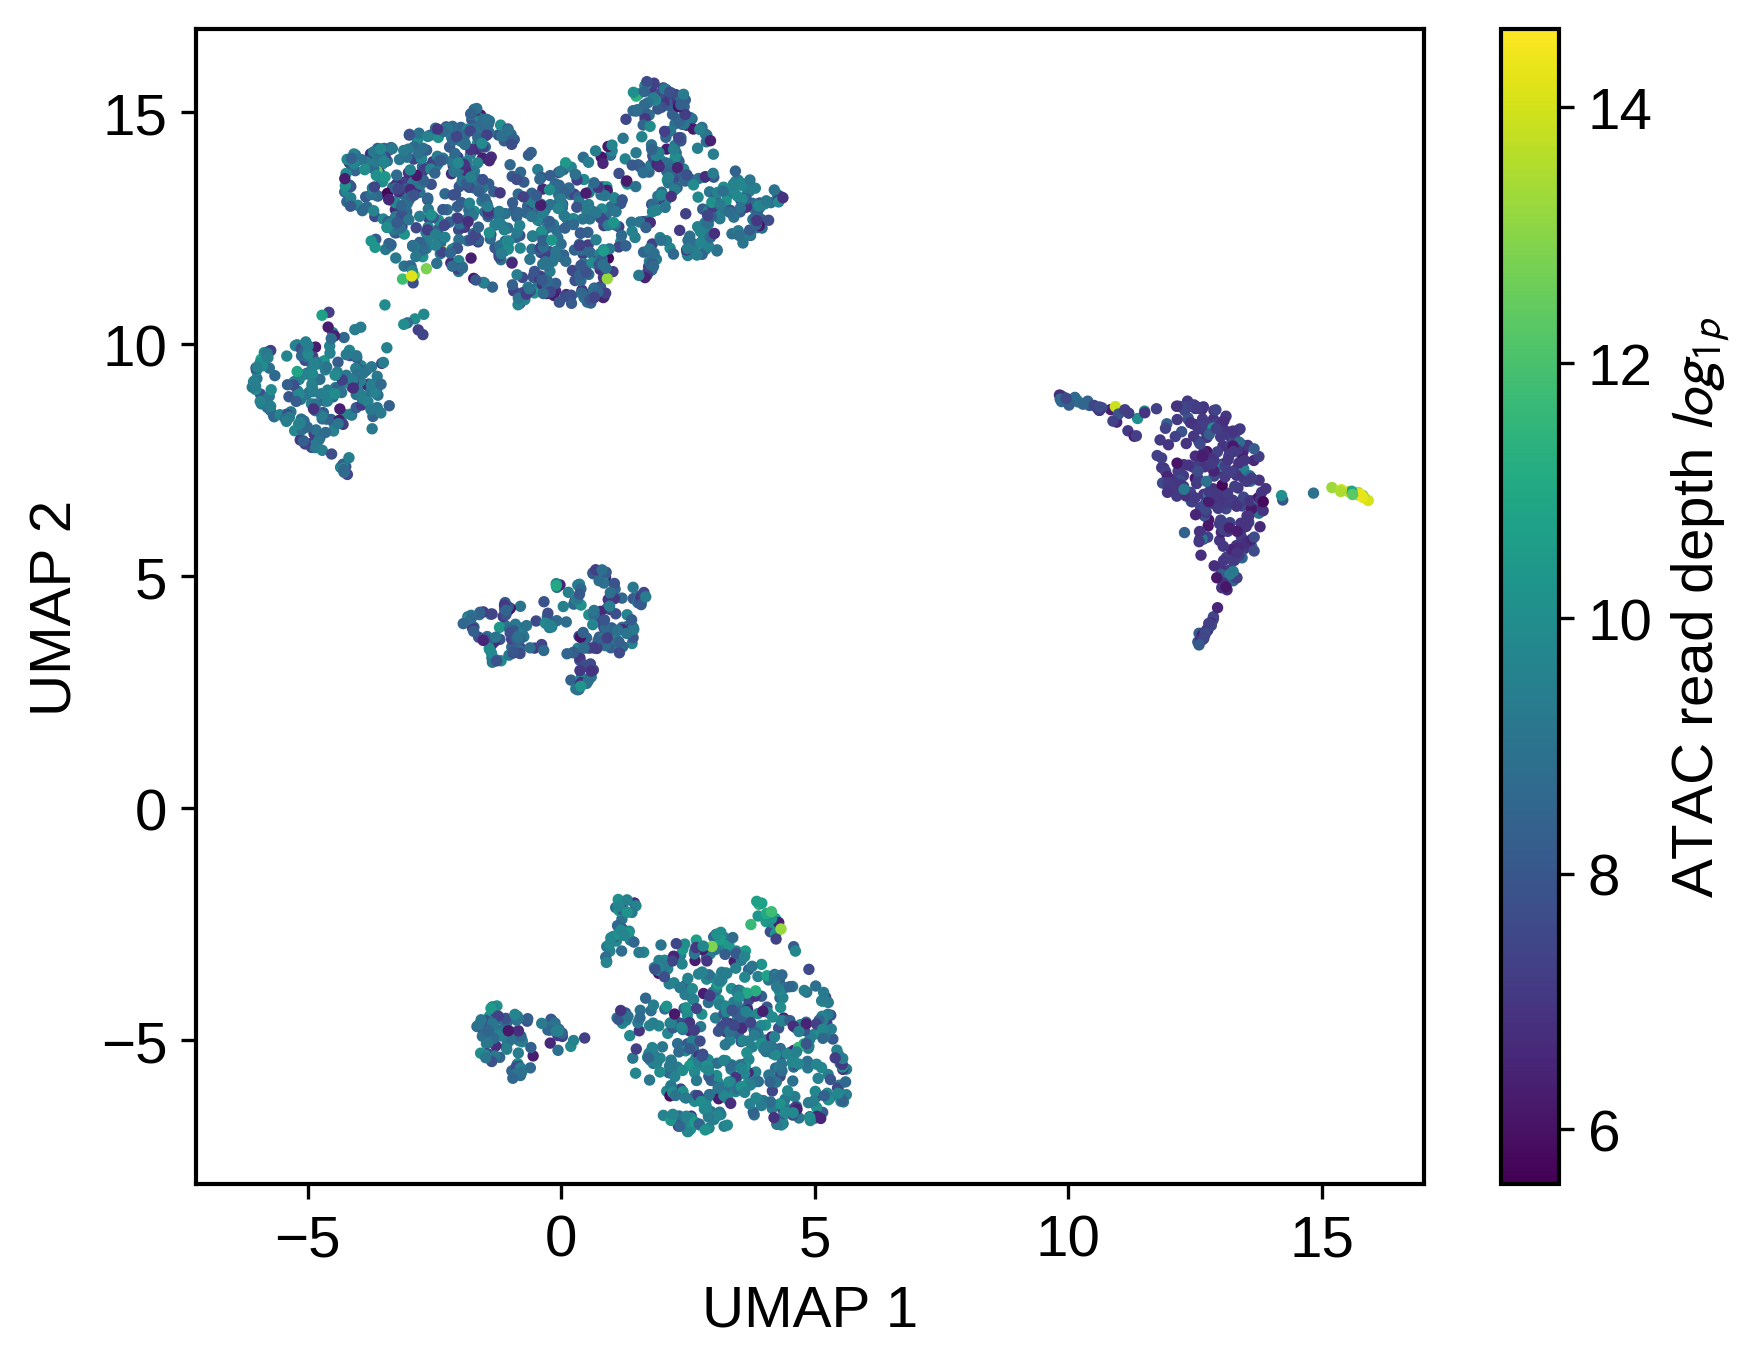

In [19]:
fig, ax = plt.subplots(figsize=(6.6, 5))

_ = ax.scatter(h5_rna_union.obsm['X_umap'][:, 0], h5_rna_union.obsm['X_umap'][:, 1], 
               s=3, c=h5_rna_union.obs['log_ATAC_read_depth'])
fig.colorbar(ax.collections[0], ax=ax, orientation='vertical', label='ATAC read depth $log_{1p}$')
# ax.set_title("RNA space umap")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

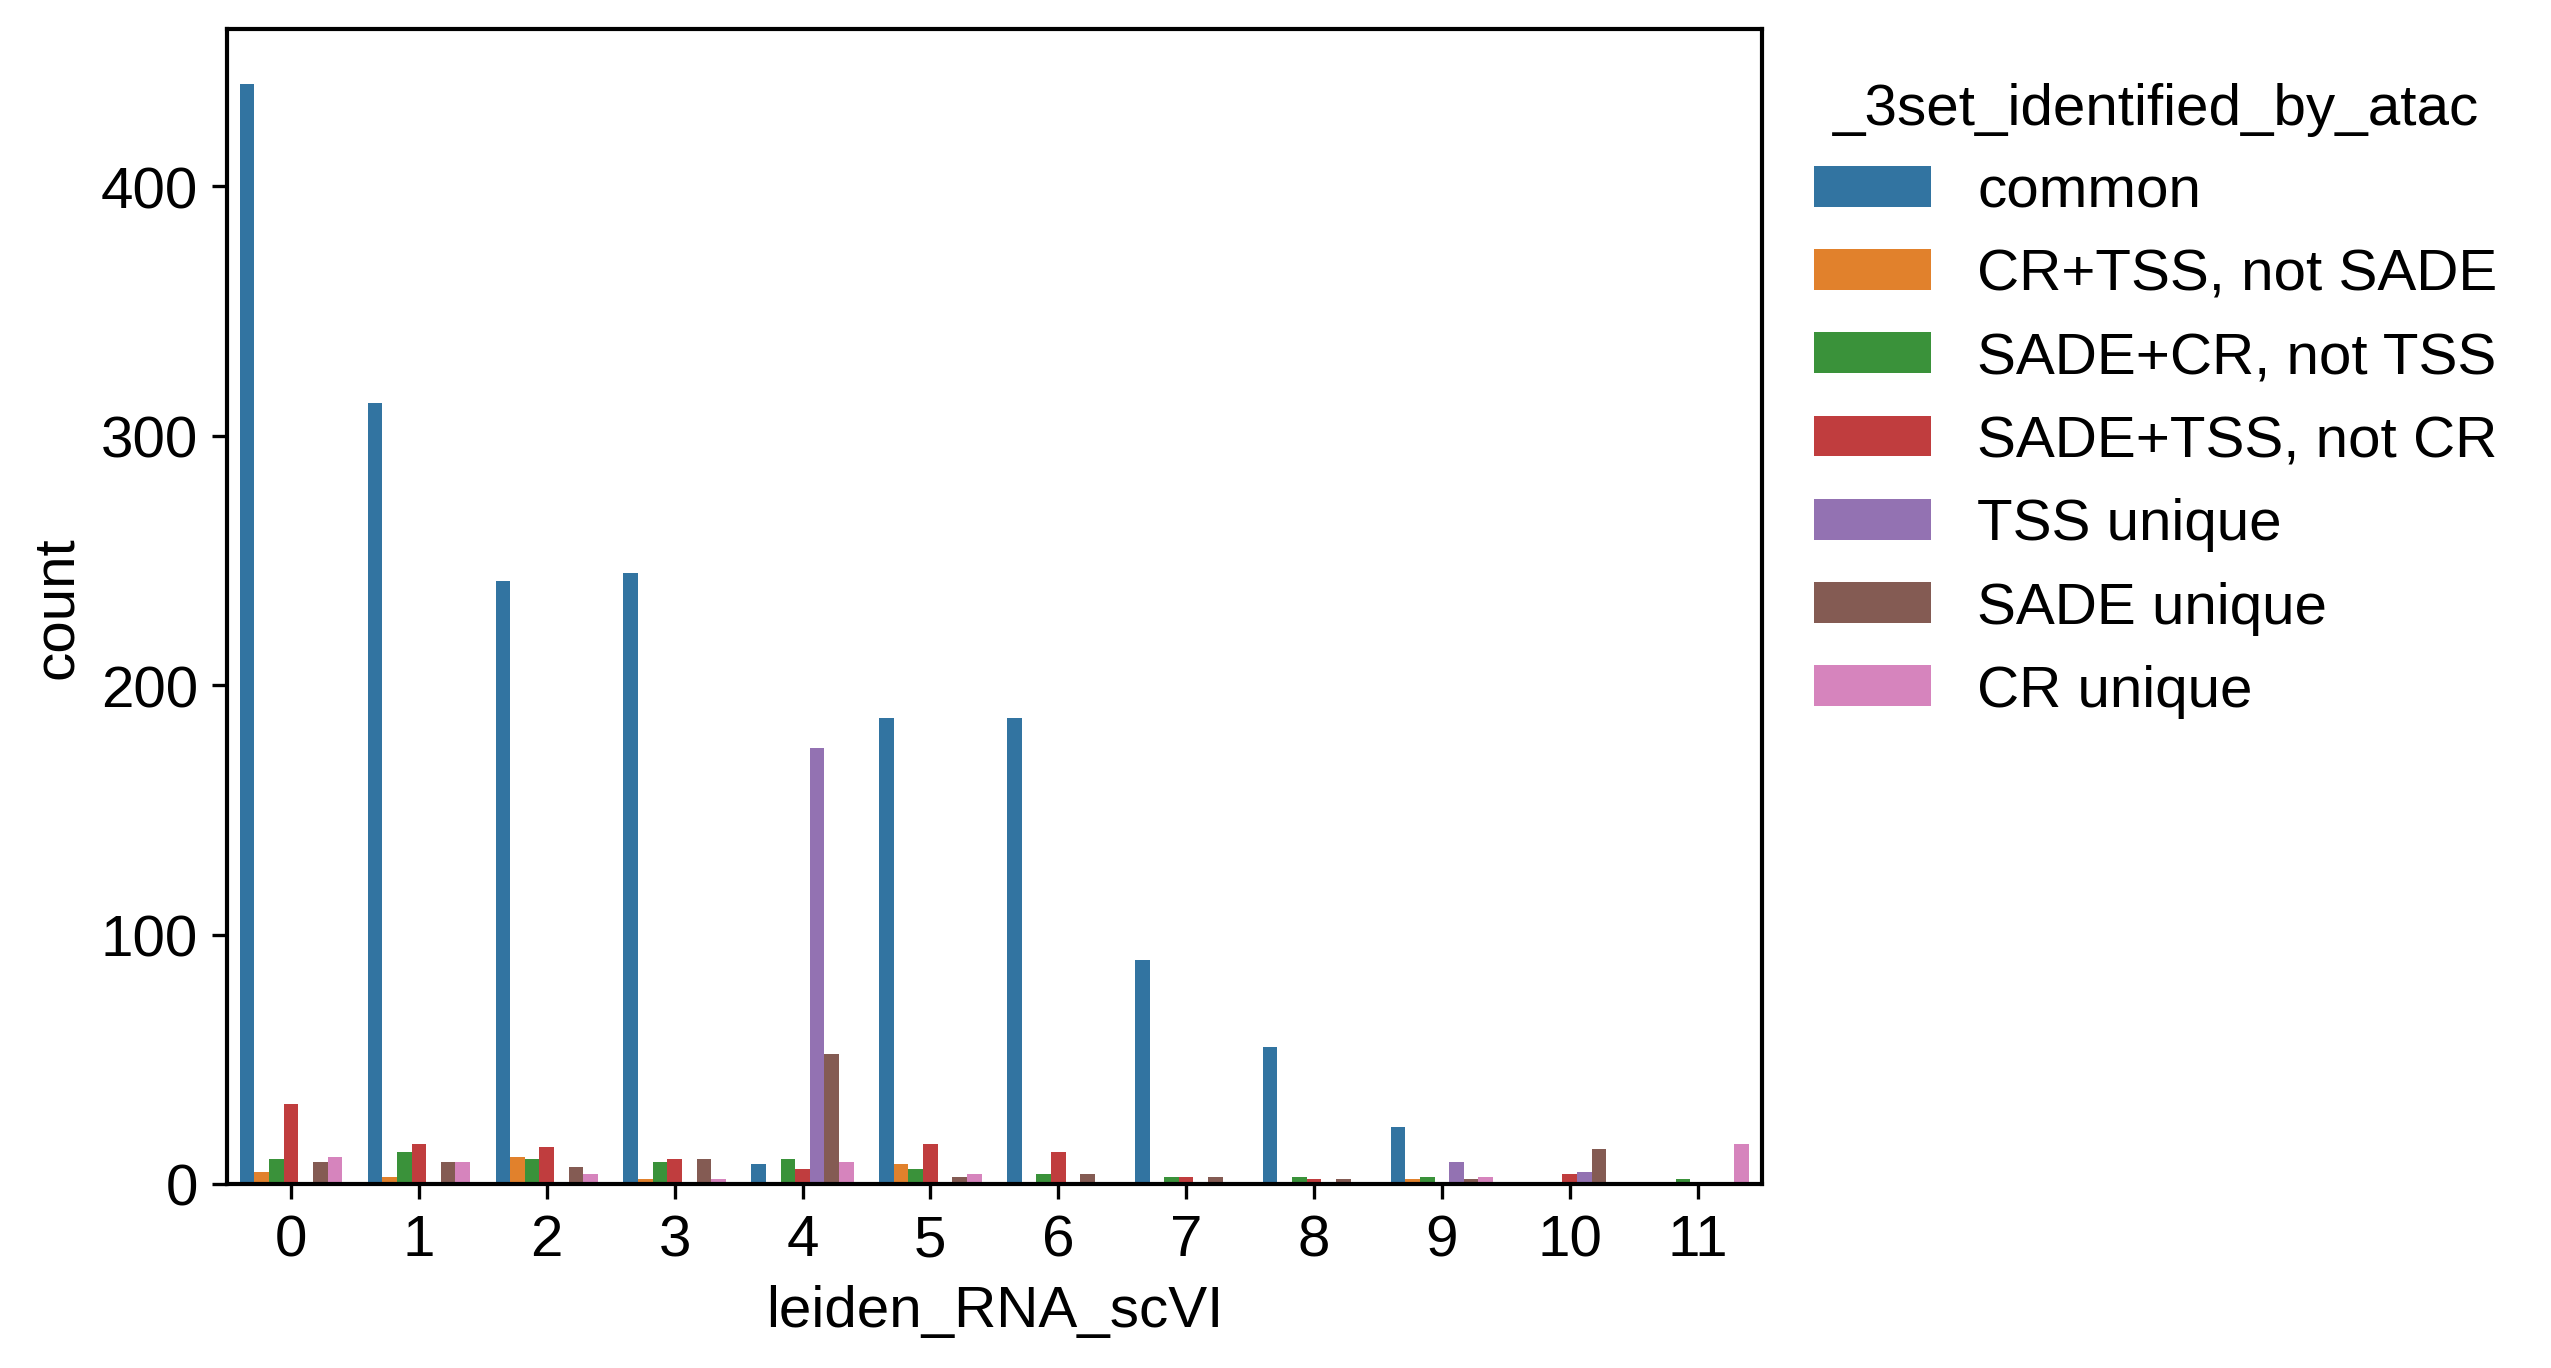

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6.6, 5))
color_dic = {'both': 'green', 'entropy_only': 'blue', 'cr_only': 'orange',   'tss_only': 'purple', 'none': 'grey', '2 out of 3': 'cyan', 'all': 'red'}

sns.countplot(data=h5_rna_union.obs, x='leiden_RNA_scVI', hue='_3set_identified_by_atac',  ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=False)


In [21]:
noisy_rna_cluster = ['4', '9', '10', '11']
cell_type_rna_clusters = [str(i) for i in range(12) if str(i) not in noisy_rna_cluster]
h5_rna_union.obs['noisy_rna_cluster'] = h5_rna_union.obs['leiden_RNA_scVI'].isin(noisy_rna_cluster)

#h5_rna_union.obs.loc[h5_rna_union.obs['leiden_RNA_scVI'].isin(cell_type_rna_clusters)].groupby([ '_3set_identified_by_atac']).size()
#h5_rna_union.obs.loc[h5_rna_union.obs['leiden_RNA_scVI'].isin(noisy_rna_cluster)].groupby([ '_3set_identified_by_atac']).size()
h5_rna_union.obs.groupby(['noisy_rna_cluster', '_3set_identified_by_atac']).size().unstack().fillna(0)

_3set_identified_by_atac,CR unique,"CR+TSS, not SADE",SADE unique,"SADE+CR, not TSS","SADE+TSS, not CR",TSS unique,common
noisy_rna_cluster,,,,,,,
False,33.0,30.0,47.0,58.0,107.0,0.0,1760.0
True,28.0,3.0,68.0,15.0,11.0,189.0,32.0


In [22]:
Ndroplets_in_any_disaggrement =  (h5_rna_union.obs['_3set_identified_by_atac'] != 'common').sum()
Ndroplets_in_any_disaggrement, (28+	3 +	68 + 	15+ 	11+	189) /Ndroplets_in_any_disaggrement

(589, 0.533106960950764)

# Bridge to ATAC QC metrics 

In [23]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)

union_bc_df['amulet_doublet_atac'] = union_bc_df.index.isin(doublet_atac_barcodes['atac_bc'])
h5_rna_union.obs['amulet_doublet_atac'] = h5_rna_union.obs['atac_barcodes'].isin(doublet_atac_barcodes['atac_bc'])

In [24]:
union_bc_df.groupby(['amulet_doublet_atac', '_3set_identified_by_atac', 'leiden_RNA_scVI', ]).size().unstack(fill_value=0)

leiden_RNA_scVI                                 0    1  10  11    2    3    4  \
amulet_doublet_atac _3set_identified_by_atac                                    
False               CR unique                  11    6   0   2    3    2    9   
                    CR+TSS, not SADE            5    3   0   0   11    2    1   
                    SADE unique                 9    9  14   0    7   10   52   
                    SADE+CR, not TSS            8   10   0   0   10    9   10   
                    SADE+TSS, not CR           32   16   4   0   15   10    6   
                    TSS unique                  0    0   5   0    0    0  175   
                    common                    432  304   0   1  228  239    8   
True                CR unique                   0    3   0  14    1    0    0   
                    SADE+CR, not TSS            2    3   0   2    0    0    0   
                    common                      9    9   0   0   14    6    0   

leiden_RNA_scVI                                 5    6   7   8   9  \
amulet_doublet_atac _3set_identified_by_atac                         
False               CR unique                   4    1   1   0   2   
                    CR+TSS, not SADE            8    0   1   0   2   
                    SADE unique                 3    4   3   2   2   
                    SADE+CR, not TSS            6    4   3   0   2   
                    SADE+TSS, not CR           16   13   3   2   1   
                    TSS unique                  0    0   0   0   9   
                    common                    184  182  87  39  23   
True                CR unique                   0    0   0   1   1   
                    SADE+CR, not TSS            0    0   0   3   1   
                    common                      3    5   3  16   0   

leiden_RNA_scVI                               no_rna_info  
amulet_doublet_atac _3set_identified_by_atac               
False               CR unique                           0  
                    CR+TSS, not SADE                    0  
                    SADE unique                         3  
                    SADE+CR, not TSS                    0  
                    SADE+TSS, not CR                    0  
                    TSS unique                          0  
                    common                              0  
True                CR unique                           0  
                    SADE+CR, not TSS                    0  
                    common                              0

In [25]:
union_bc_df.groupby(['amulet_doublet_atac', 'leiden_RNA_scVI', ]).size().unstack(fill_value=0)

leiden_RNA_scVI,0,1,10,11,2,3,4,5,6,7,8,9,no_rna_info
amulet_doublet_atac,,,,,,,,,,,,,
False,497,348,23,3,274,272,261,221,204,98,43,41,3
True,11,15,0,16,15,6,0,3,5,3,20,2,0


In [26]:
union_bc_df.groupby(['amulet_doublet_atac', '_3set_identified_by_atac']).size().unstack(fill_value=0)

_3set_identified_by_atac,CR unique,"CR+TSS, not SADE",SADE unique,"SADE+CR, not TSS","SADE+TSS, not CR",TSS unique,common
amulet_doublet_atac,,,,,,,
False,41,33,118,62,118,189,1727
True,20,0,0,11,0,0,65


In [27]:
h5_rna_union.obs.groupby(['amulet_doublet_atac', 'DNA_debris']).size().unstack(fill_value=0) 

DNA_debris,NO,YES
amulet_doublet_atac,,
False,2283,2
True,76,20


In [28]:
h5_rna_union.obs['debris_doublets_flag'] = h5_rna_union.obs.apply(lambda row: 
    'debrisNdoublet' if row['DNA_debris'] == 'YES' and row['amulet_doublet_atac'] == True \
        else ('doublets' if row['amulet_doublet_atac'] == True \
            else ('Debris' if row['DNA_debris'] == 'YES' else 'clean')), axis=1)

In [29]:
h5_rna_union.obs.groupby(['debris_doublets_flag', '_3set_identified_by_atac', 'leiden_RNA_scVI', ]).size().unstack(fill_value=0)

/tmp/ipykernel_1496253/3215059344.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_union.obs.groupby(['debris_doublets_flag', '_3set_identified_by_atac', 'leiden_RNA_scVI', ]).size().unstack(fill_value=0)


leiden_RNA_scVI                                  0    1    2    3    4    5  \
debris_doublets_flag _3set_identified_by_atac                                 
Debris               CR unique                   0    0    0    0    0    0   
                     CR+TSS, not SADE            0    0    0    0    0    0   
                     SADE unique                 0    0    0    0    0    0   
                     SADE+CR, not TSS            0    0    0    0    0    0   
                     SADE+TSS, not CR            0    0    0    0    0    0   
                     TSS unique                  0    0    0    0    0    0   
                     common                      0    0    0    0    0    0   
clean                CR unique                  11    6    3    2    9    4   
                     CR+TSS, not SADE            5    3   11    2    1    8   
                     SADE unique                 9    9    7   10   52    3   
                     SADE+CR, not TSS            8   10   10    9   10    6   
                     SADE+TSS, not CR           32   16   15   10    6   16   
                     TSS unique                  0    0    0    0  175    0   
                     common                    432  304  228  239    8  184   
debrisNdoublet       CR unique                   0    3    1    0    0    0   
                     CR+TSS, not SADE            0    0    0    0    0    0   
                     SADE unique                 0    0    0    0    0    0   
                     SADE+CR, not TSS            0    0    0    0    0    0   
                     SADE+TSS, not CR            0    0    0    0    0    0   
                     TSS unique                  0    0    0    0    0    0   
                     common                      0    0    0    0    0    0   
doublets             CR unique                   0    0    0    0    0    0   
                     CR+TSS, not SADE            0    0    0    0    0    0   
                     SADE unique                 0    0    0    0    0    0   
                     SADE+CR, not TSS            2    3    0    0    0    0   
                     SADE+TSS, not CR            0    0    0    0    0    0   
                     TSS unique                  0    0    0    0    0    0   
                     common                      9    9   14    6    0    3   

leiden_RNA_scVI                                  6   7   8   9  10  11  
debris_doublets_flag _3set_identified_by_atac                           
Debris               CR unique                   0   0   0   0   0   2  
                     CR+TSS, not SADE            0   0   0   0   0   0  
                     SADE unique                 0   0   0   0   0   0  
                     SADE+CR, not TSS            0   0   0   0   0   0  
                     SADE+TSS, not CR            0   0   0   0   0   0  
                     TSS unique                  0   0   0   0   0   0  
                     common                      0   0   0   0   0   0  
clean                CR unique                   1   1   0   2   0   0  
                     CR+TSS, not SADE            0   1   0   2   0   0  
                     SADE unique                 4   3   2   2  14   0  
                     SADE+CR, not TSS            4   3   0   2   0   0  
                     SADE+TSS, not CR           13   3   2   1   4   0  
                     TSS unique                  0   0   0   9   5   0  
                     common                    182  87  39  23   0   1  
debrisNdoublet       CR unique                   0   0   1   1   0  14  
                     CR+TSS, not SADE            0   0   0   0   0   0  
                     SADE unique                 0   0   0   0   0   0  
                     SADE+CR, not TSS            0   0   0   0   0   0  
                     SADE+TSS, not CR            0   0   0   0   0   0  
                     TSS unique                  0   0   0   0   0   0  
                     co

In [30]:
atac_flag_cat = ['clean', 'doublets', 'debrisNdoublet', 'Debris']
atac_flag_labels = ['Clean', 'Doublets', 'Debris+Doublets', 'Debris']
atac_flag_label_map = dict(zip(atac_flag_cat, atac_flag_labels))

atac_flag_alpha_map = {f: a for f, a in zip(atac_flag_cat, [0.7, 0.7, 0.7, 0.7])}
atac_flag_hatch_map = {f: h for f, h in zip(atac_flag_cat, ['', '//', '\\\\', '..'])}

/tmp/ipykernel_1496253/1415661373.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag'] == unq_flag].groupby(['leiden_RNA_scVI', '_3set_identified_by_atac'] ).size().unstack(fill_value=0)
/tmp/ipykernel_1496253/1415661373.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag'] == unq_flag].groupby(['leiden_RNA_scVI', '_3set_identified_by_atac'] ).size().unstack(fill_value=0)
/tmp/ipykernel_1496253/1415661373.py:12: FutureWarning: The default of observed=False is deprecated and will be chan

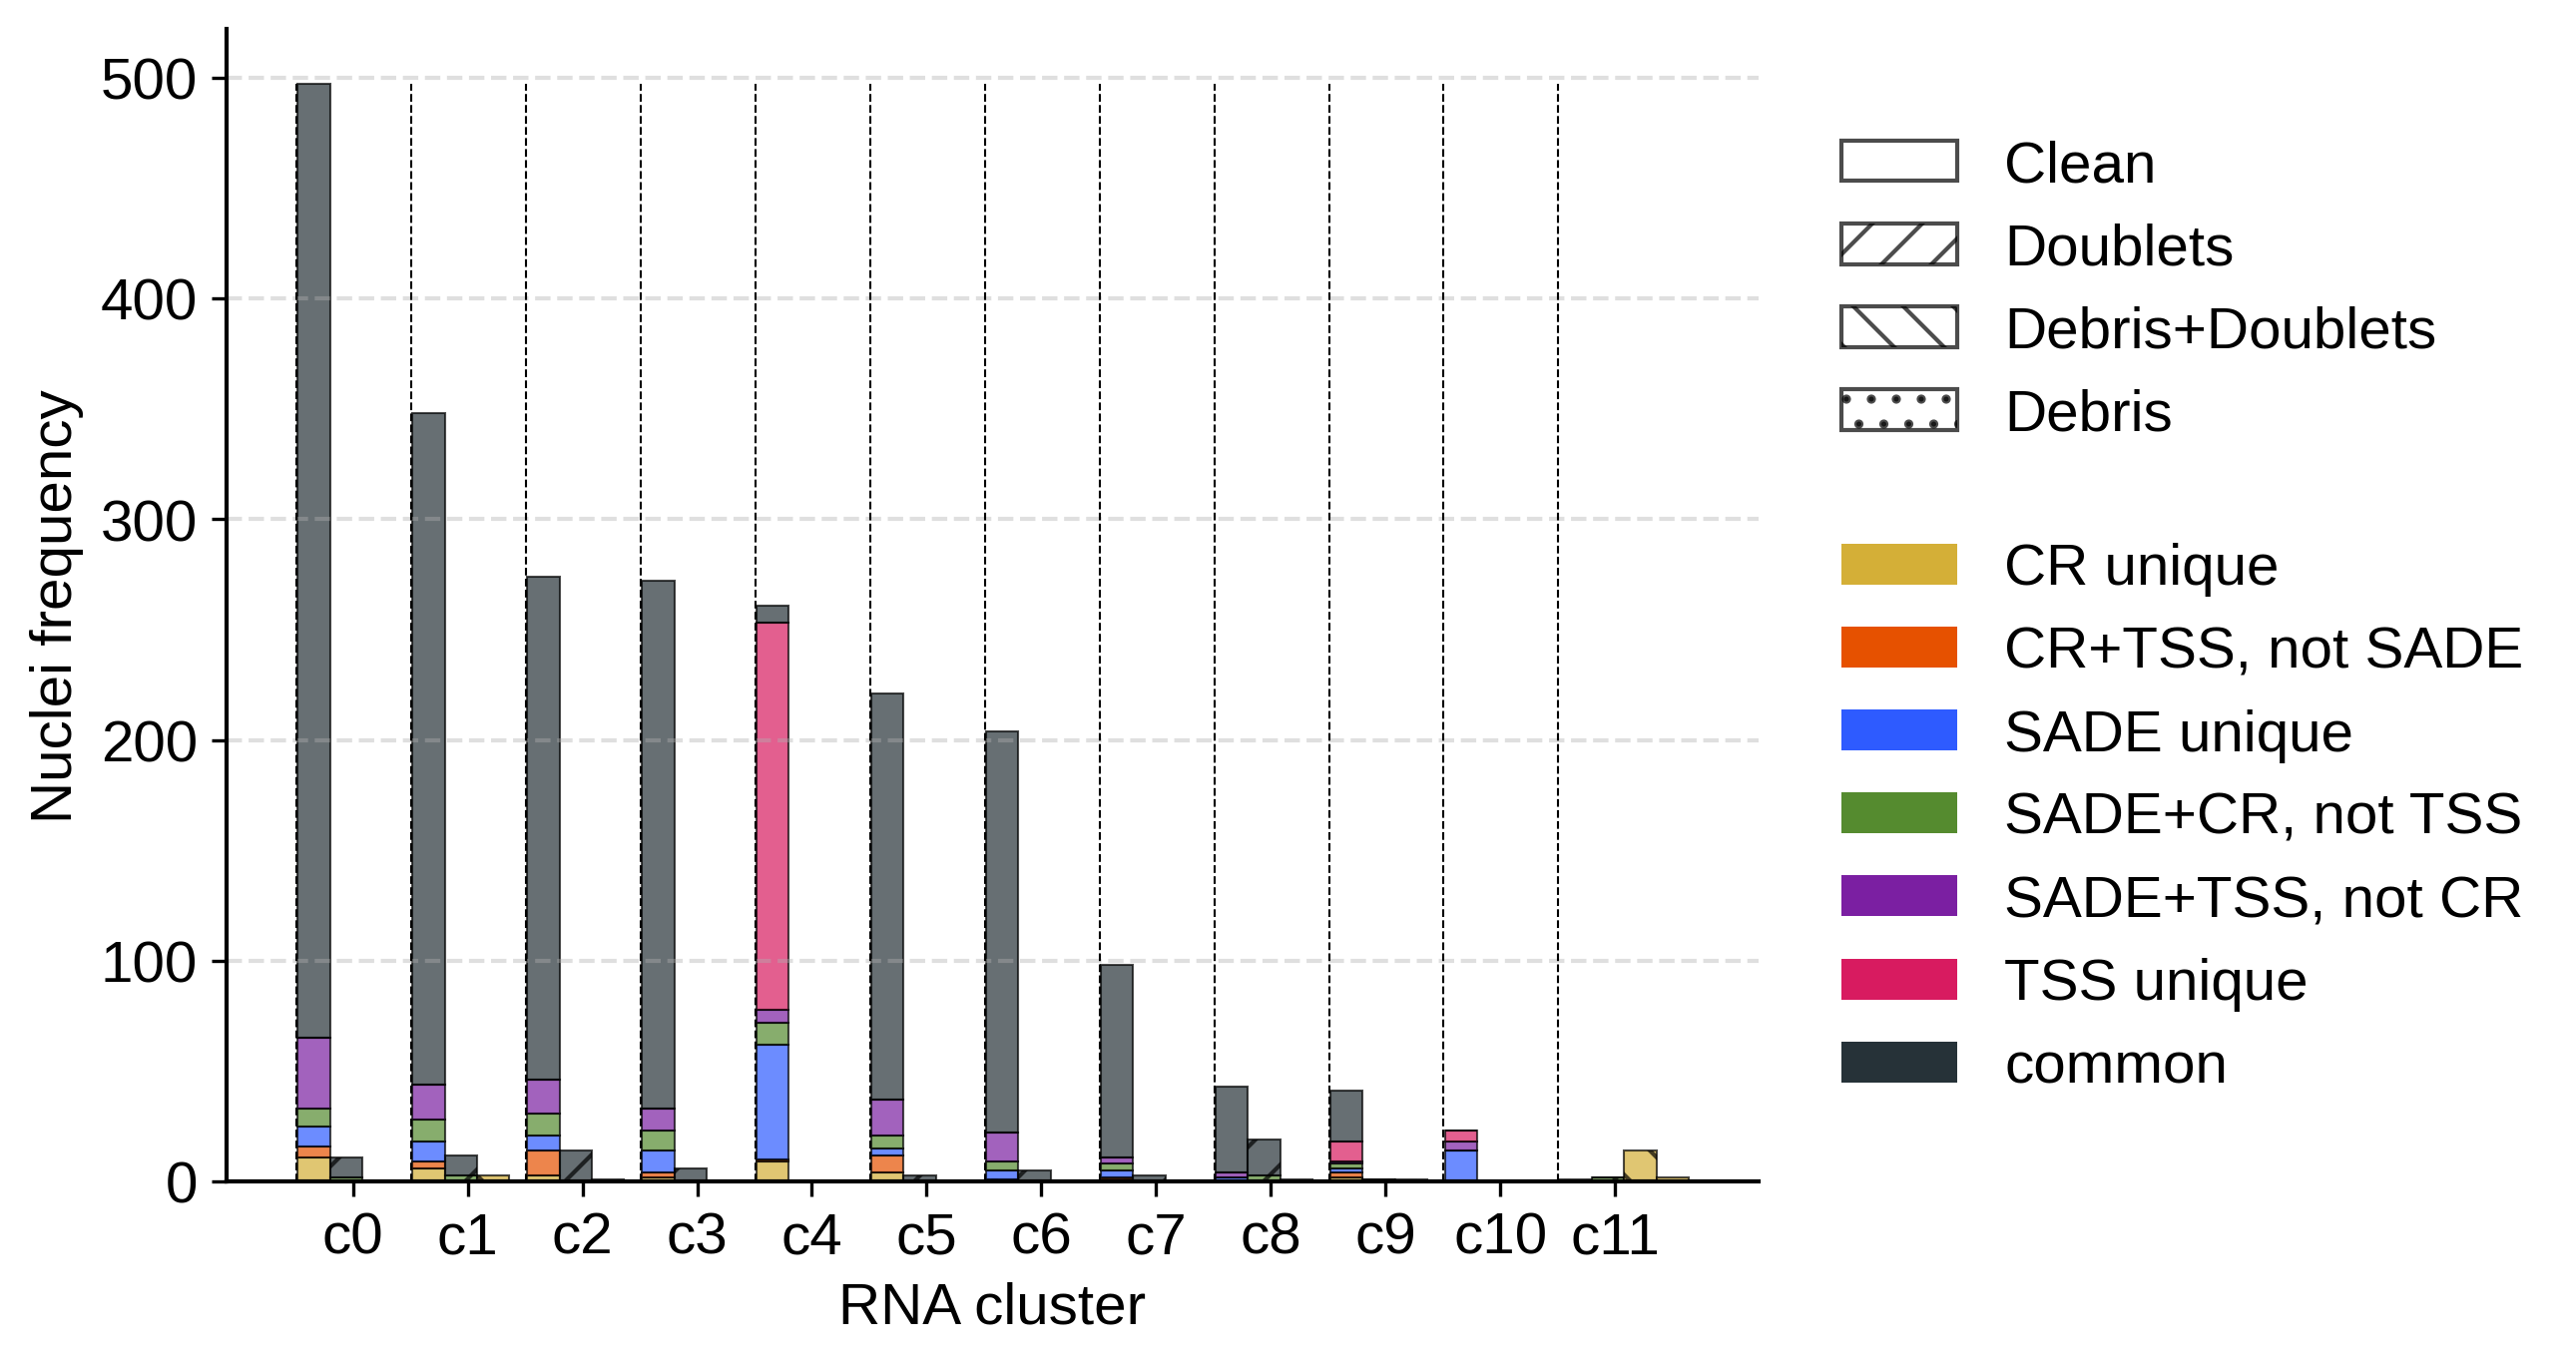

In [31]:

flags = h5_rna_union.obs['debris_doublets_flag'].unique()


fig, ax = plt.subplots(figsize=(6.6, 5))
group_spacing = 2.5 
width = 0.7
legend_handles = {}


for i, unq_flag in enumerate(atac_flag_cat):

    df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag'] == unq_flag].groupby(['leiden_RNA_scVI', '_3set_identified_by_atac'] ).size().unstack(fill_value=0)

    x_positions = np.arange(len(df)) * group_spacing + 0.7 * i  # 1.5 spacing instead of 1.0

    # Filter: Only keep X-axis categories (columns) that have a total count > 0
    pivot_df = df.loc[:, df.sum(axis=0) > 0]
    bottom = np.zeros(len(pivot_df))
    # Only plot type that actually have cells (non-zero frequencies)
    for type in pivot_df.columns:
        heights = pivot_df[type].values
        
        if heights.sum() > 0:  # Only add to plot if the type exists in the data
            color = cat_colors_map.get(str(type), 'red')

            bar = ax.bar(x_positions, 
                heights, 
                bottom=bottom, 
                label=f"{type}", 
                color=color,
                width=width, 
                alpha=atac_flag_alpha_map[unq_flag],
                hatch=atac_flag_hatch_map[unq_flag],
                edgecolor='black',
                linewidth=0.5)
            
            if type not in legend_handles:
                legend_handles[type] = Patch(facecolor=color, label=f"{type}")
            bottom += heights
    if i == 0:  # Add flag legend only once
        ax.vlines(x_positions - width/2 * 1.1, 0, bottom.max(), color='black', linestyle='--', linewidth=0.5)

flag_elements = [Patch(facecolor='white', edgecolor='black', alpha=atac_flag_alpha_map[f], hatch=atac_flag_hatch_map[f], label=atac_flag_label_map[f]) for f in flags]
leg_flags = ax.legend(handles=flag_elements, title="", 
                      bbox_to_anchor=(1.02, 0.95), loc='upper left', frameon=False)
ax.add_artist(leg_flags)

# # legend 2 
sorted_keys = sorted(legend_handles.keys(), key=lambda x: int(x) if str(x).isdigit() else 99)
sorted_handles = [legend_handles[k] for k in sorted_keys]
ax.legend(handles=sorted_handles, title="", 
          bbox_to_anchor=(1.02, 0.60), loc='upper left', ncol=1, frameon=False)

## 
ax.set_xticks(x_positions - group_spacing/2)  # Center the ticks between groups
ax.set_xticklabels(['c' + str(label) for label in pivot_df.index], rotation=0, ha='center')

ax.set_ylabel("Nuclei frequency")
ax.set_xlabel("RNA cluster")
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


In [32]:
debris_or_doublet_cat= ['clean', 'doublets', 'debrisNdoublet', 'Debris']
debris_or_doublet_map = dict(zip(debris_or_doublet_cat, ['#FFFFFF',  "#a50026", '#a50026', "#a50026"]))

pass_cr_map = { False: "#a50026"}


In [33]:
Tcells= ['IL7R',] #'CD3G', 'CD3E', 'CD3D',  ] 
B_cell = ['MS4A1', 'CD79A']# , 'CD19', ]
NK = [ 'FCGR3A', 'NCAM1'] # NKG7',FCGR3A', 'NCAM1'
mono = [ 'CD14',   'CD68',   ]# ,  CD14, FCGR1A, CD68
naiveTcells = [ "CCR7",	  ]#  "CCR7",	 'IL7R',
DC=[  'CD1C',  ] # 'SERPINF1',  
cytotoxic_T = ['CD8A', 'CD8B',]
#mono_or_DC = ['HLA-DRA'] # for umap 
#naiveThelper = [   'CD4', ] # for umap 

housekeeping_genes = ['GNB1', 'PRPF38B',  'CDC42SE1', 'PPP2R5A',] # 'CMPK1', 'COX7A2L', 'SF3B1', 'CTDSP1']

marker_genes_redor =Tcells  + naiveTcells +  cytotoxic_T+  NK+ mono + DC + B_cell    + housekeeping_genes 


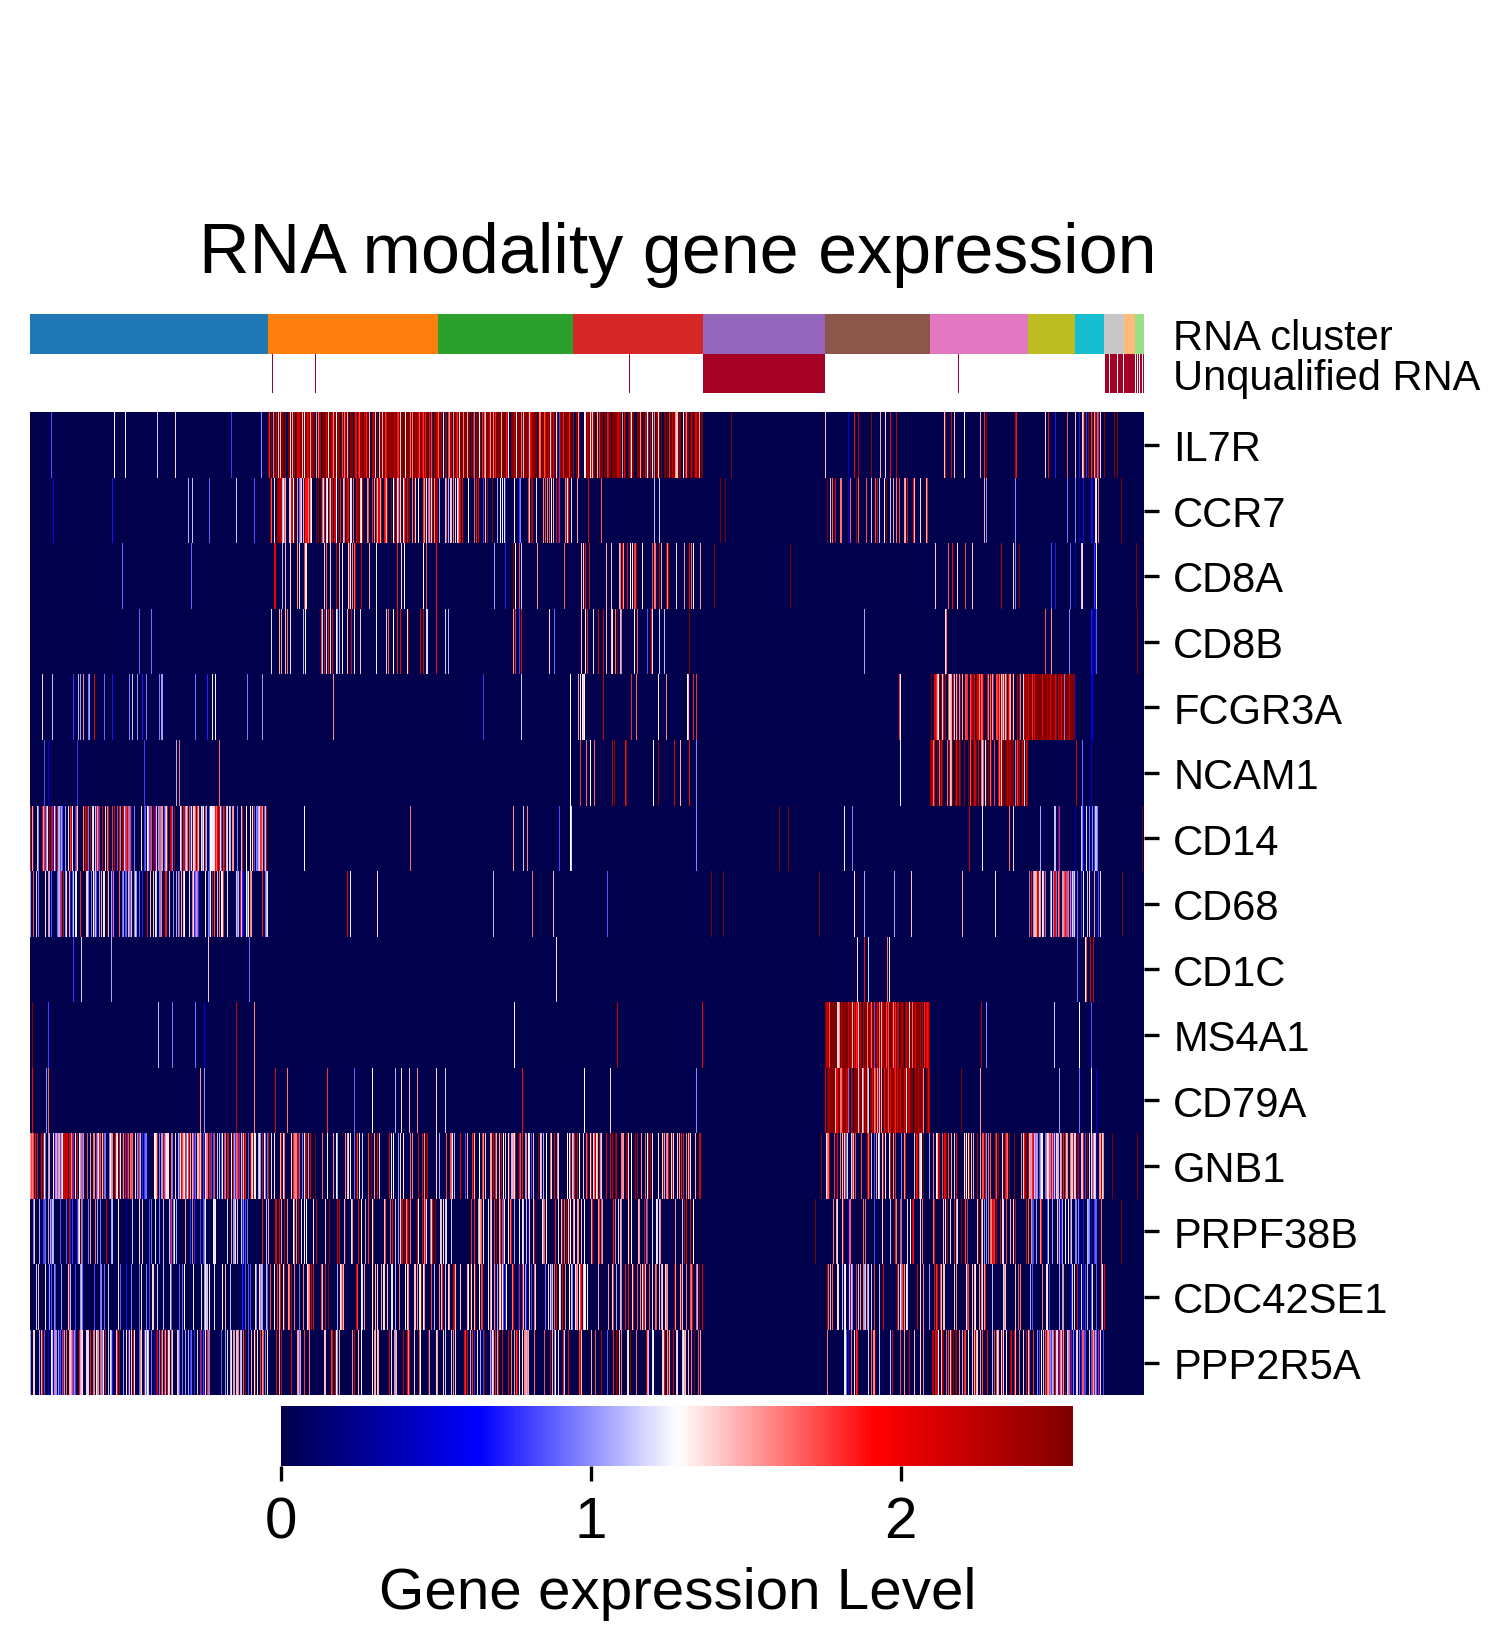

In [ ]:
h5_rna_union.var_names_make_unique()               


mat = h5_rna_union[:, marker_genes_redor].layers['log1p_cpm'].toarray()
df = pd.DataFrame(mat, index=h5_rna_union.obs.index, columns= marker_genes_redor).T

vmean = df.values.mean()
vsd = df.values.std()
vmin= 0.
vmax = np.min((df.values.max(), vmean + 3*vsd))
vcenter = vmax/2


#Create metadata for the columns
metadata = h5_rna_union.obs[['leiden_RNA_scVI', '_3set_identified_by_atac','rna_pass_CR', 'total_RNA_UMI_log']].copy()


norm = mcolors.Normalize(vmin=metadata['total_RNA_UMI_log'].min(), vmax=metadata['total_RNA_UMI_log'].max())
mapper = cm.ScalarMappable(norm=norm, cmap='viridis')
col_colors = pd.DataFrame({
    'RNA cluster': metadata['leiden_RNA_scVI'].map(scanpy_color_map) ,
    #'_3set_identified_by_atac': metadata['_3set_identified_by_atac'].map(cat_colors_map),
    'Unqualified RNA': metadata['rna_pass_CR'].map(pass_cr_map)
    #f'Total RNA UMI $(log)$': metadata['total_RNA_UMI_log'].apply(lambda x: mcolors.to_hex(mapper.to_rgba(x))), 
}, index=metadata.index)


num_color_rows = col_colors.shape[1]
dynamic_ratio = 0.02 * num_color_rows

# 4. Plot the clustermap
cell_index = h5_rna_union.obs['leiden_RNA_scVI'].sort_values().index

g = sns.clustermap(df.loc[:, cell_index], col_colors=col_colors.loc[cell_index], cmap='seismic', linewidths=0, 
                   figsize=(6.6, 5), col_cluster=False, xticklabels=False, row_cluster=False, yticklabels=True,
                   cbar_pos=(0.3, 0.0, 0.4, 0.04), # Horizontal bar at bottom center
                   cbar_kws={"orientation": "horizontal", 'label': 'Gene expression Level'}, #colors_ratio=dynamic_ratio,
                   vmin=vmin, vmax=vmax, center=vcenter
                  )
g.tick_params(axis='y', labelsize=10)
g.ax_heatmap.tick_params(axis='y', labelsize=10)
g.ax_row_dendrogram.set_visible(False) # Hide Row tree
g.ax_col_colors.tick_params(axis='y', labelsize=10,    labelright=True, right=False)

# umi_cax = g.fig.add_axes([0.43, 0.9, 0.15, 0.02]) 
# cb = plt.colorbar(mapper, cax=umi_cax, orientation='horizontal', label='Total RNA UMI ($log$)')


g.fig.suptitle('RNA modality gene expression', 
               y=0.83) #
g.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p2.png'), bbox_inches='tight', dpi=600)
g.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p2.pdf'), bbox_inches='tight')


In [35]:
# Save index for ATAC heat map plot's consistency
h5_rna_union.obs.loc[cell_index, ['rna_barcodes', 'atac_barcodes']].to_csv(os.path.join(Union_cell_subdir, '_unioncell_rna_order_index.csv')) 

In [36]:
h5_rna_union.obs.groupby(['DNA_debris', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_1496253/399134367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_union.obs.groupby(['DNA_debris', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,2,3,4,5,6,7,8,9,10,11
DNA_debris,,,,,,,,,,,,
NO,508,360,288,278,261,224,209,101,62,42,23,3
YES,0,3,1,0,0,0,0,0,1,1,0,16


In [37]:
h5_rna_union.obs.groupby(['rna_pass_CR', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_1496253/863021169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_union.obs.groupby(['rna_pass_CR', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,2,3,4,5,6,7,8,9,10,11
rna_pass_CR,,,,,,,,,,,,
False,1,2,0,2,261,0,1,0,0,37,23,10
True,507,361,289,276,0,224,208,101,63,6,0,9


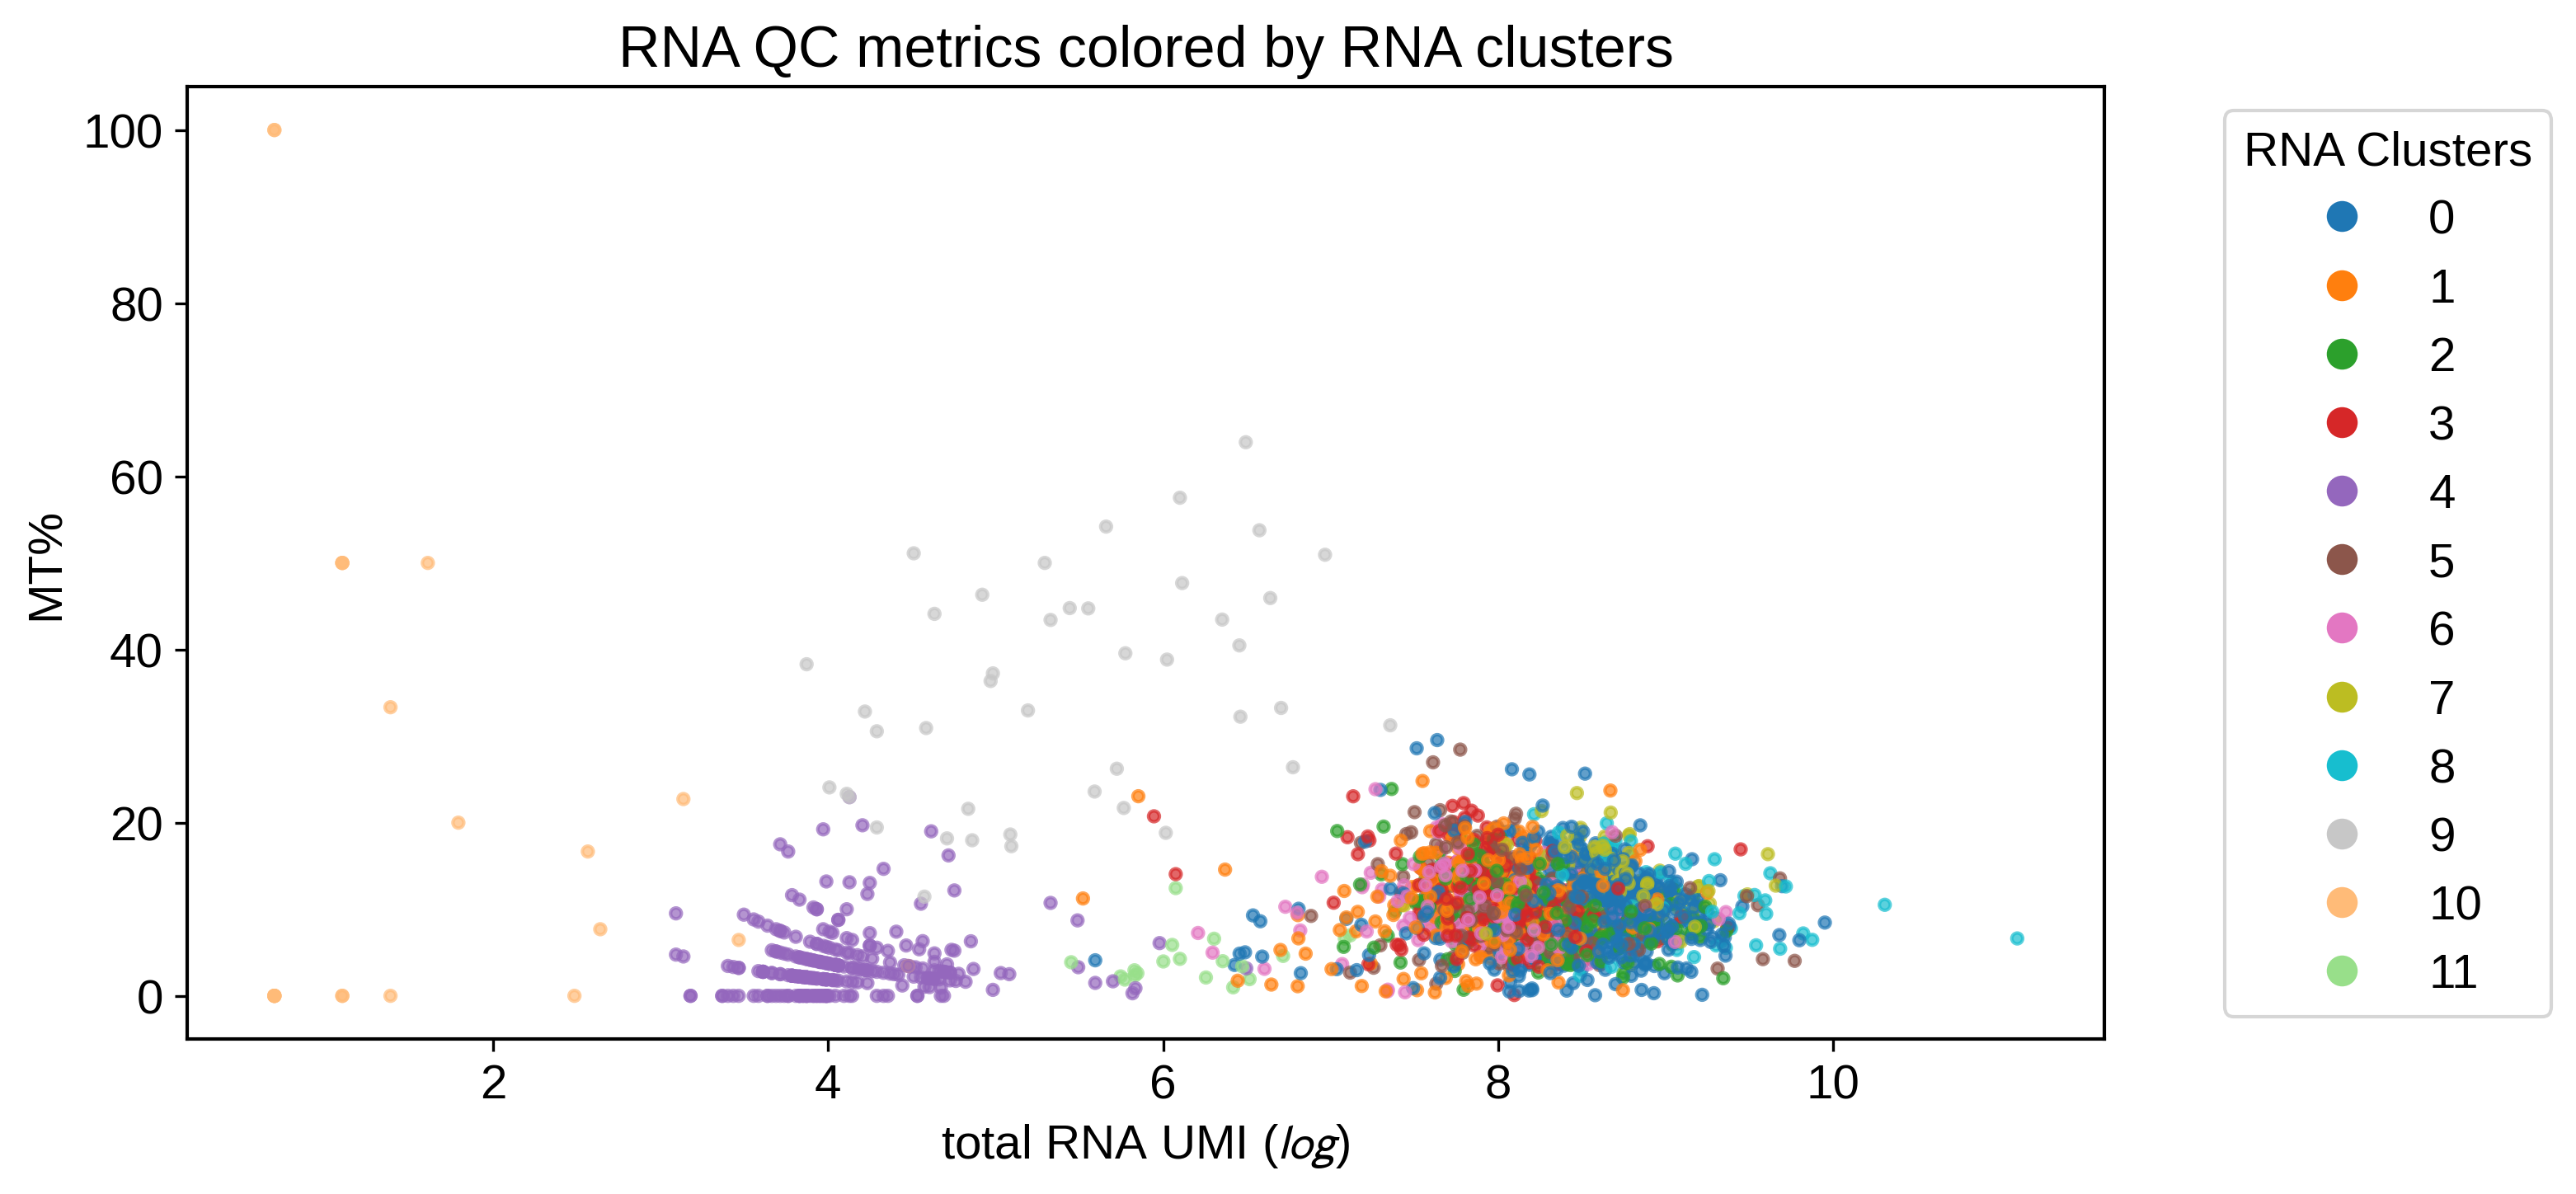

In [38]:

fig, ax = plt.subplots(figsize=(10, 5))
_ = ax.scatter(h5_rna_union.obs['total_RNA_UMI_log'], h5_rna_union.obs['MT%'], c=h5_rna_union.obs['leiden_RNA_scVI'].map(scanpy_color_map), alpha=0.7, s=10)
ax.set_xlabel('total RNA UMI ($log$)')
ax.set_ylabel('MT%')
ax.set_title('RNA QC metrics colored by RNA clusters')
legend_elements = [Line2D([0], [0], marker='o', color='w', label=cluster, markerfacecolor=color, markersize=10) for cluster, color in scanpy_color_map.items()]
ax.legend(handles=legend_elements, title='RNA Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

In [39]:
union_bc_df['leiden_RNA_scVI'] = union_bc_df.index.map(h5_rna_union.obs.set_index('atac_barcodes')['leiden_RNA_scVI'])
union_bc_df['leiden_RNA_scVI'] = union_bc_df['leiden_RNA_scVI'].cat.add_categories('no_rna_info')
union_bc_df['leiden_RNA_scVI'] = union_bc_df['leiden_RNA_scVI'].fillna('no_rna_info')

union_bc_df['leiden_RNA_scVI'].value_counts()

leiden_RNA_scVI
0              508
1              363
2              289
3              278
4              261
5              224
6              209
7              101
8               63
9               43
10              23
11              19
no_rna_info      3
Name: count, dtype: int64

# Focus on CR vs SADE 

In [40]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 1 + [jitter_width] * 3  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))

In [41]:
h5_rna_union.obs['_2set_identified_by_atac_SC_mod'] = h5_rna_union.obs['_2set_identified_by_atac_SC'].replace('none', 'tss_only')
h5_rna_union.obs['debris_doublets_flag_mod'] = h5_rna_union.obs['debris_doublets_flag'].replace({'clean': 'clean', 'doublets': 'debrisORdoublets', 'debrisNdoublet': 'debrisORdoublets', 'Debris': 'debrisORdoublets'})

/tmp/ipykernel_1496253/3942029172.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag_mod'] == unq_flag].groupby(['leiden_RNA_scVI', '_2set_identified_by_atac_SC_mod'] ).size().unstack(fill_value=0)
/tmp/ipykernel_1496253/3942029172.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag_mod'] == unq_flag].groupby(['leiden_RNA_scVI', '_2set_identified_by_atac_SC_mod'] ).size().unstack(fill_value=0)


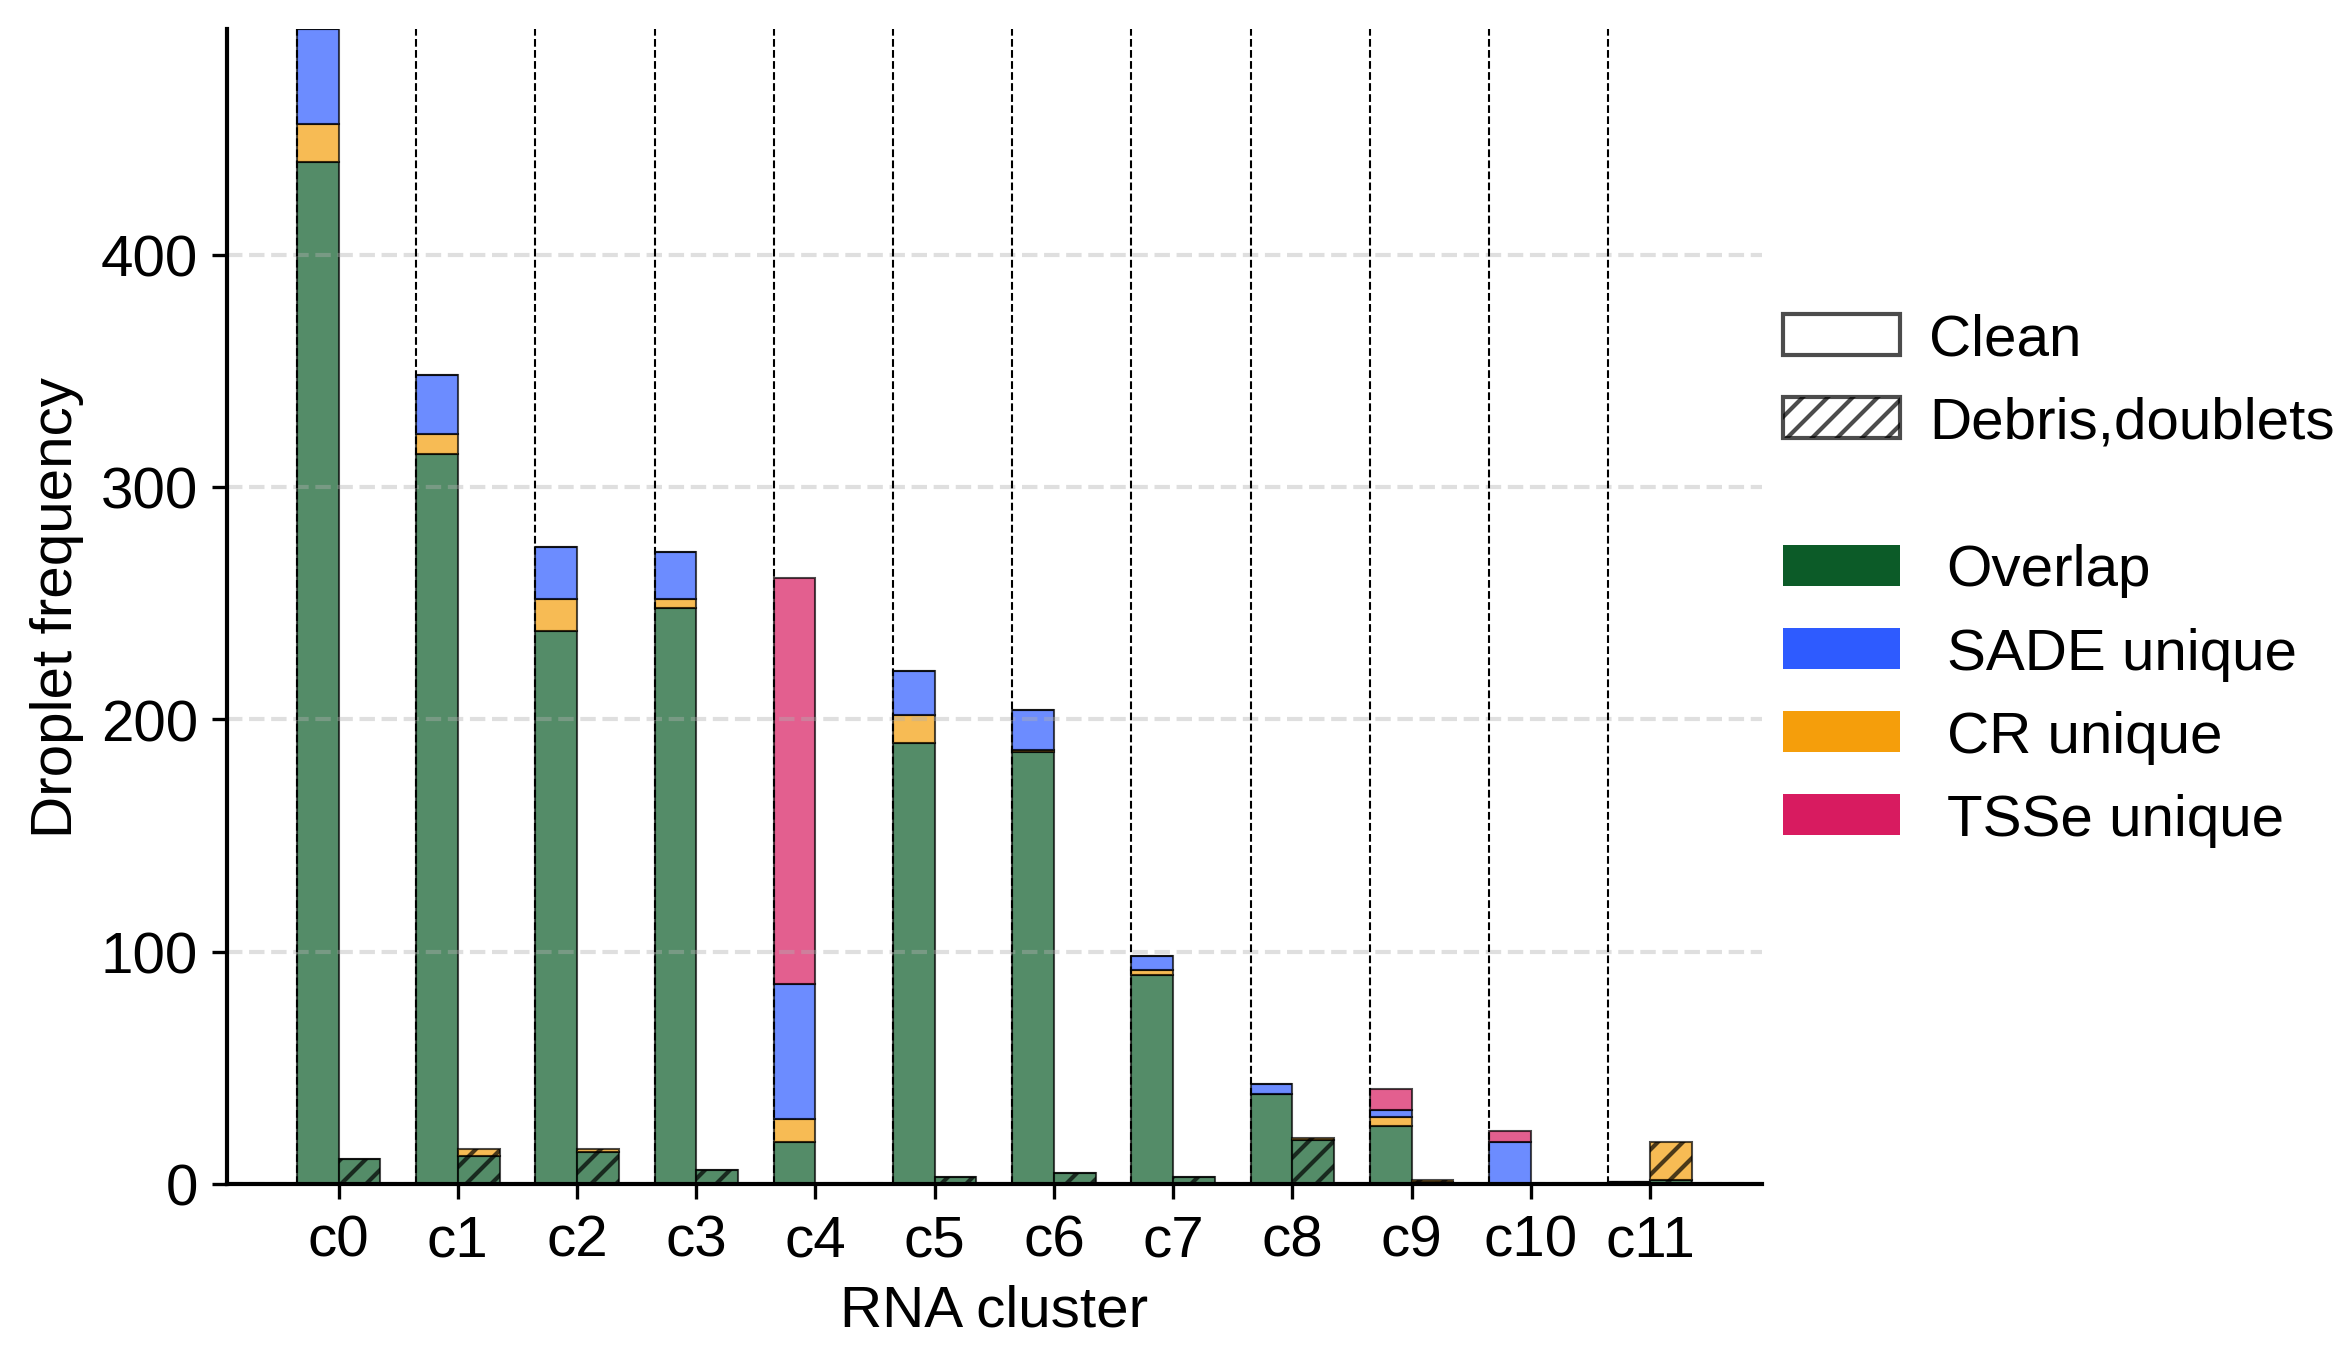

In [42]:
atac_flag_cat = ['clean', 'debrisORdoublets']
atac_flag_labels = ['Clean', 'Debris,doublets']
atac_flag_label_map = dict(zip(atac_flag_cat, atac_flag_labels))

atac_flag_alpha_map = {f: a for f, a in zip(atac_flag_cat, [0.7, 0.7])}
atac_flag_hatch_map = {f: h for f, h in zip(atac_flag_cat, ['', '////'])}

flags = h5_rna_union.obs['debris_doublets_flag_mod'].unique()


fig, ax = plt.subplots(figsize=(6.6, 5))
group_spacing = 2 
width = 0.7
legend_handles = {}


for i, unq_flag in enumerate(atac_flag_cat):

    df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag_mod'] == unq_flag].groupby(['leiden_RNA_scVI', '_2set_identified_by_atac_SC_mod'] ).size().unstack(fill_value=0)

    x_positions = np.arange(len(df)) * group_spacing + 0.7 * i  

    # Filter: Only keep X-axis categories (columns) that have a total count > 0
    pivot_df = df.loc[:, df.sum(axis=0) > 0]
    bottom = np.zeros(len(pivot_df))
    # Only plot type that actually have cells (non-zero frequencies)
    for type in pivot_df.columns:
        heights = pivot_df[type].values
        
        if heights.sum() > 0:  # Only add to plot if the type exists in the data
            color = SADEvsCR_colors_map.get(str(type), 'red')

            bar = ax.bar(x_positions, 
                heights, 
                bottom=bottom, 
                label=f"{type}", 
                color=color,
                width=width, 
                alpha=atac_flag_alpha_map[unq_flag],
                hatch=atac_flag_hatch_map[unq_flag],
                edgecolor='black',
                linewidth=0.5)
            
            if type not in legend_handles:
                legend_handles[type] = Patch(facecolor=color, label=f"{type}")
            bottom += heights
    if i == 0:  # Add flag legend only once
        ax.vlines(x_positions - width/2 , 0, bottom.max(), color='black', linestyle='--', linewidth=0.5)

flag_elements = [Patch(facecolor='white', edgecolor='black', alpha=atac_flag_alpha_map[f], hatch=atac_flag_hatch_map[f], label=atac_flag_label_map[f]) for f in flags]
leg_flags = ax.legend(handles=flag_elements, title="",  bbox_to_anchor=(0.98, 0.80), loc='upper left', frameon=False,  handletextpad=0.5)
ax.add_artist(leg_flags)

# # legend 2 

sorted_handles = [Patch(facecolor=SADEvsCR_colors_map[k], label=SADEvsCR_label_map[k]) for k in SADEvsCR_unique_categoris if k in legend_handles]
ax.legend(handles=sorted_handles, title="", 
          bbox_to_anchor=(0.98, 0.60), loc='upper left', ncol=1, frameon=False)

## 
ax.set_xticks(x_positions - width/2)  # Center the ticks between groups
ax.set_xticklabels(['c' + str(label) for label in pivot_df.index], rotation=0, ha='center')

ax.set_ylabel("Droplet frequency")
ax.set_xlabel("RNA cluster")
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p3.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p3.pdf'), bbox_inches='tight')
